In [333]:

###################################################################
########## IMPORTS DES LIBRAIRIES - FORMATS - CHEMINS... ##########
###################################################################

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


import sys

import json


from datetime import datetime
from dateutil.relativedelta import relativedelta


In [334]:
# Lecture des données
df_retail = pd.read_excel('table_modelisation.xlsx')
df_retail.head()

,code_commune,nom_commune,logements_10_19_ans_2017,logements_10_19_ans_2023,logements_1_piece_2017,logements_1_piece_2023,logements_20_29_ans_2017,logements_20_29_ans_2023,logements_2_4_ans_2017,logements_2_4_ans_2023,...,lycee_2025,urgences_2025,pharmacie_2025,gare_nationale_2025,gare_regionale_2025,transport_ferroviaire_local_rer_metro_transilien_2025,salle_non_specialisee_sport_2025,bowling_2025,salle_remise_en_forme_2025,gymnase_multisports_2025
0,75056,Paris,234759.08383,198821.63183,263138.04296,261901.41711,117450.31250,138351.28940,267134.39926,271313.38030,...,173.0,16.0,864.0,7.0,27.0,0.0,88.0,6.0,244.0,267.0
1,77001,Achères-la-Forêt,148.58681,140.32916,8.54964,1.06465,67.95784,82.42404,55.83149,66.53873,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,77002,Amillis,78.56030,63.12739,8.94991,13.15892,42.76067,48.77921,53.69945,58.80329,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,77003,Amponville,33.25740,31.96659,1.07533,1.01446,28.77046,28.05571,13.09390,20.93649,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,77004,Andrezel,25.99447,12.37905,1.01003,0.00000,29.96052,18.37894,8.96456,25.64638,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Initialisation de la table d'analyse

In [335]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Conservation de df_data comme table source
df_modele = df_retail.copy()

print("Dimensions de la table :", df_modele.shape)
display(df_modele.head())

Dimensions de la table : (1266, 102)


,code_commune,nom_commune,logements_10_19_ans_2017,logements_10_19_ans_2023,logements_1_piece_2017,logements_1_piece_2023,logements_20_29_ans_2017,logements_20_29_ans_2023,logements_2_4_ans_2017,logements_2_4_ans_2023,...,lycee_2025,urgences_2025,pharmacie_2025,gare_nationale_2025,gare_regionale_2025,transport_ferroviaire_local_rer_metro_transilien_2025,salle_non_specialisee_sport_2025,bowling_2025,salle_remise_en_forme_2025,gymnase_multisports_2025
0,75056,Paris,234759.08383,198821.63183,263138.04296,261901.41711,117450.31250,138351.28940,267134.39926,271313.38030,...,173.0,16.0,864.0,7.0,27.0,0.0,88.0,6.0,244.0,267.0
1,77001,Achères-la-Forêt,148.58681,140.32916,8.54964,1.06465,67.95784,82.42404,55.83149,66.53873,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,77002,Amillis,78.56030,63.12739,8.94991,13.15892,42.76067,48.77921,53.69945,58.80329,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,77003,Amponville,33.25740,31.96659,1.07533,1.01446,28.77046,28.05571,13.09390,20.93649,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,77004,Andrezel,25.99447,12.37905,1.01003,0.00000,29.96052,18.37894,8.96456,25.64638,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [336]:
df_modele.shape

(1266, 102)

#### Vérification des colonnes disponibles

In [337]:
pd.set_option("display.max_rows", None)

colonnes_df = pd.DataFrame({
    "colonne": df_modele.columns,
    "type": df_modele.dtypes.astype(str).values
})

# display(colonnes_df)
df_modele.head()

,code_commune,nom_commune,logements_10_19_ans_2017,logements_10_19_ans_2023,logements_1_piece_2017,logements_1_piece_2023,logements_20_29_ans_2017,logements_20_29_ans_2023,logements_2_4_ans_2017,logements_2_4_ans_2023,...,lycee_2025,urgences_2025,pharmacie_2025,gare_nationale_2025,gare_regionale_2025,transport_ferroviaire_local_rer_metro_transilien_2025,salle_non_specialisee_sport_2025,bowling_2025,salle_remise_en_forme_2025,gymnase_multisports_2025
0,75056,Paris,234759.08383,198821.63183,263138.04296,261901.41711,117450.31250,138351.28940,267134.39926,271313.38030,...,173.0,16.0,864.0,7.0,27.0,0.0,88.0,6.0,244.0,267.0
1,77001,Achères-la-Forêt,148.58681,140.32916,8.54964,1.06465,67.95784,82.42404,55.83149,66.53873,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,77002,Amillis,78.56030,63.12739,8.94991,13.15892,42.76067,48.77921,53.69945,58.80329,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,77003,Amponville,33.25740,31.96659,1.07533,1.01446,28.77046,28.05571,13.09390,20.93649,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,77004,Andrezel,25.99447,12.37905,1.01003,0.00000,29.96052,18.37894,8.96456,25.64638,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Audit qualité du dataset

#### Indentification des valeurs manquantes

In [338]:
# Taux de valeurs manquantes par variable
taux_manquants = df_modele.isna().mean()

variables_a_supprimer = taux_manquants[
    taux_manquants >= 0.90
].index.tolist()

print("Variables à supprimer (>= 90 % de manquants) :")
print(variables_a_supprimer)

print("\nNombre de variables supprimées :", len(variables_a_supprimer))

Variables à supprimer (>= 90 % de manquants) :
[]

Nombre de variables supprimées : 0


In [339]:
display(
    (
        taux_manquants[
            taux_manquants >= 0.90
        ] * 100
    )
    .sort_values(ascending=False)
    .to_frame("pct_manquant")
)

,pct_manquant


In [340]:
df_modele = df_modele.drop(
    columns=variables_a_supprimer
)

print("Nouvelles dimensions :", df_modele.shape)

Nouvelles dimensions : (1266, 102)


In [341]:
cles_analytiques = [
    "code_commune",
    "nom_commune"
]

doublons = df_modele.duplicated(
    subset=cles_analytiques,
    keep=False
)

print(
    "Nombre de lignes appartenant à des clés dupliquées :",
    doublons.sum()
)

Nombre de lignes appartenant à des clés dupliquées : 0


In [342]:
if doublons.any():
    display(
        df_modele.loc[doublons]
        .sort_values(cles_analytiques)
    )
else:
    print(
        "La granularité est respectée : "
        "une ligne par commune."
    )

La granularité est respectée : une ligne par commune.


In [343]:
# Controle nombre d'obervation par clé
controle_unicite = (
    df_modele
    .groupby(cles_analytiques, dropna=False)
    .size()
    .reset_index(name="nombre_lignes")
    .sort_values("nombre_lignes", ascending=False)
)

display(controle_unicite.head(10))

,code_commune,nom_commune,nombre_lignes
0,75056,Paris,1
1,77001,Achères-la-Forêt,1
2,77002,Amillis,1
3,77003,Amponville,1
4,77004,Andrezel,1
5,77005,Annet-sur-Marne,1
6,77006,Arbonne-la-Forêt,1
7,77007,Argentières,1
8,77008,Armentières-en-Brie,1
9,77009,Arville,1


In [344]:
df_modele = df_modele.drop(
    columns=variables_a_supprimer
)

print("Nouvelles dimensions :", df_modele.shape)

Nouvelles dimensions : (1266, 102)


In [345]:
controle_na=(
    df_modele
    .isna()
    .sum()
    .reset_index()
)

controle_na.columns=["variable", "nb_valeurs_manquantes"]
controle_na['pct_manquant'] = (
    controle_na['nb_valeurs_manquantes']
    / len(df_modele)
    *100
)

# display(controle_na
#         .sort_values("pct_manquant", ascending=False)
# )


In [346]:
# Imputation de la médiane aux colonnes qui ont des valeurs manquantes

# BON A SAVOIR : certaines valeurs sont à 0 dans les infrastructures parce qu'ils n'avaient vraiement pas ces infrastructures

# Liste complète de toutes les colonnes envoyées
colonnes_a_imputer = [
    'taux_pauvrete_60_2023',
    'gymnase_multisports_2025',
    'librairie_2025',
    'banque_2025',
    'bureau_de_poste_2025',
    'restauration_rapide_2025',
    'hypermarche_grand_magasin_2025',
    'superette_2025',
    'epicerie_2025',
    'boulangerie_patisserie_2025',
    'magasin_vetements_2025',
    'magasin_chaussures_2025',
    'magasin_meubles_2025',
    'parfumerie_cosmetique_2025',
    'electromenager_audio_video_informatique_2025',
    'supermarche_2025',
    'papeterie_presse_2025',
    'gare_nationale_2025',
    'salle_remise_en_forme_2025',
    'ecole_maternelle_2025',
    'bowling_2025',
    'transport_ferroviaire_local_rer_metro_transilien_2025',
    'gare_regionale_2025',
    'salle_non_specialisee_sport_2025',
    'pharmacie_2025',
    'urgences_2025',
    'lycee_2025',
    'college_2025',
    'ecole_elementaire_2025',
    'ecole_primaire_2025',
    'niveau_vie_median_2023',
    'population_hommes_40_54_ans_2023',
]

# Imputation de la médiane pour toutes ces colonnes d'un seul coup
df_modele[colonnes_a_imputer] = df_modele[colonnes_a_imputer].fillna(
    df_modele[colonnes_a_imputer].median()
)
df_modele.head()

,code_commune,nom_commune,logements_10_19_ans_2017,logements_10_19_ans_2023,logements_1_piece_2017,logements_1_piece_2023,logements_20_29_ans_2017,logements_20_29_ans_2023,logements_2_4_ans_2017,logements_2_4_ans_2023,...,lycee_2025,urgences_2025,pharmacie_2025,gare_nationale_2025,gare_regionale_2025,transport_ferroviaire_local_rer_metro_transilien_2025,salle_non_specialisee_sport_2025,bowling_2025,salle_remise_en_forme_2025,gymnase_multisports_2025
0,75056,Paris,234759.08383,198821.63183,263138.04296,261901.41711,117450.31250,138351.28940,267134.39926,271313.38030,...,173.0,16.0,864.0,7.0,27.0,0.0,88.0,6.0,244.0,267.0
1,77001,Achères-la-Forêt,148.58681,140.32916,8.54964,1.06465,67.95784,82.42404,55.83149,66.53873,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,77002,Amillis,78.56030,63.12739,8.94991,13.15892,42.76067,48.77921,53.69945,58.80329,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,77003,Amponville,33.25740,31.96659,1.07533,1.01446,28.77046,28.05571,13.09390,20.93649,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,77004,Andrezel,25.99447,12.37905,1.01003,0.00000,29.96052,18.37894,8.96456,25.64638,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Création des colonnes sur l'évolution annuelle

In [347]:
import numpy as np

# Colonnes qui ne doivent pas être traitées
colonnes_exclues = ["code_commune", "nom_commune"]

df = df_modele.copy()

# On récupère toutes les colonnes se terminant par _2017
colonnes_2017 = [
    col for col in df.columns
    if col.endswith("_2017") and col not in colonnes_exclues
]


# Création des évolutions
for col_2017 in colonnes_2017:

    # Nom de la variable de base
    base = col_2017[:-5]  # enlève "_2017"

    # Colonne 2023 correspondante
    col_2023 = f"{base}_2023"

    # On ne traite que les variables ayant bien 2017 ET 2023
    if col_2023 in df.columns:

        # Évolution absolue
        df[f"{base}_delta_2017_2023"] = (
            df[col_2023] - df[col_2017]
        )

        # Évolution relative en %
        df[f"{base}_evolution_2017_2023"] = np.where(
            df[col_2017].notna() & (df[col_2017] != 0),
            ((df[col_2023] - df[col_2017]) / df[col_2017]) * 100,
            np.nan
        )

df.head()

,code_commune,nom_commune,logements_10_19_ans_2017,logements_10_19_ans_2023,logements_1_piece_2017,logements_1_piece_2023,logements_20_29_ans_2017,logements_20_29_ans_2023,logements_2_4_ans_2017,logements_2_4_ans_2023,...,population_hommes_25_39_ans_delta_2017_2023,population_hommes_25_39_ans_evolution_2017_2023,population_hommes_40_54_ans_delta_2017_2023,population_hommes_40_54_ans_evolution_2017_2023,population_hommes_55_64_ans_delta_2017_2023,population_hommes_55_64_ans_evolution_2017_2023,population_hommes_65_ans_et_plus_delta_2017_2023,population_hommes_65_ans_et_plus_evolution_2017_2023,population_hommes_moins_de_15_ans_delta_2017_2023,population_hommes_moins_de_15_ans_evolution_2017_2023
0,75056,Paris,234759.08383,198821.63183,263138.04296,261901.41711,117450.31250,138351.28940,267134.39926,271313.38030,...,-11669.53510,-4.265330,-16836.58972,-8.113318,1000.82365,0.900305,4119.57820,2.752919,-17820.36536,-11.589789
1,77001,Achères-la-Forêt,148.58681,140.32916,8.54964,1.06465,67.95784,82.42404,55.83149,66.53873,...,13.29013,22.589146,-28.25435,-16.694918,39.18535,57.493255,24.56255,29.644927,-3.86233,-4.147712
2,77002,Amillis,78.56030,63.12739,8.94991,13.15892,42.76067,48.77921,53.69945,58.80329,...,-4.33646,-6.056571,5.06318,6.691456,-3.02660,-4.342341,3.75386,4.974297,-12.57537,-15.807193
3,77003,Amponville,33.25740,31.96659,1.07533,1.01446,28.77046,28.05571,13.09390,20.93649,...,-1.12243,-4.163240,-14.34071,-26.085311,4.49865,18.253760,3.09836,10.321471,11.24267,48.714887
4,77004,Andrezel,25.99447,12.37905,1.01003,0.00000,29.96052,18.37894,8.96456,25.64638,...,10.24162,48.968314,-2.56029,-7.147286,-7.39838,-23.102380,4.42418,22.063458,16.50792,61.804361


In [348]:
colonnes_evolution = [
    col for col in df.columns
    if "_evolution_2017_2023" in col
]

df[colonnes_evolution].describe().T

,count,mean,std,min,25%,50%,75%,max
logements_10_19_ans_evolution_2017_2023,1265.0,-5.743306,21.621870,-64.772386,-16.689234,-7.500084,1.682170,272.856401
logements_1_piece_evolution_2017_2023,1057.0,11.356833,81.611265,-100.000000,-23.008558,1.086735,30.459559,824.764957
logements_20_29_ans_evolution_2017_2023,1265.0,17.792574,34.913256,-100.000000,-0.003256,14.376647,28.544533,431.564207
logements_2_4_ans_evolution_2017_2023,1264.0,21.017036,40.221659,-66.632490,-0.765053,12.626813,32.459894,288.154810
logements_2_pieces_evolution_2017_2023,1248.0,14.918373,59.056186,-100.000000,-9.587844,7.952606,27.576566,800.000000
logements_30_ans_ou_plus_evolution_2017_2023,1266.0,11.098300,23.839166,-73.321677,-1.491855,7.256874,19.476224,327.239573
logements_3_pieces_evolution_2017_2023,1265.0,9.267478,33.023737,-100.000000,-5.520978,6.223607,19.055948,341.339059
logements_4_pieces_evolution_2017_2023,1266.0,2.940157,19.176667,-66.666667,-6.438061,0.976476,9.756705,158.097115
logements_5_9_ans_evolution_2017_2023,1266.0,19.780510,53.708707,-73.571379,-4.456382,11.546835,33.080069,803.576663
logements_5_pieces_ou_plus_evolution_2017_2023,1266.0,7.880093,8.876739,-24.201564,2.445777,6.696446,12.466288,75.997964


In [349]:
df[colonnes_evolution].isna().mean().sort_values(ascending=False)

travaille_hors_france_ou_non_precise_evolution_2017_2023                0.392575
logements_1_piece_evolution_2017_2023                                   0.165087
travaille_hors_region_evolution_2017_2023                               0.018957
logements_2_pieces_evolution_2017_2023                                  0.014218
logements_2_4_ans_evolution_2017_2023                                   0.001580
population_hommes_65_ans_et_plus_evolution_2017_2023                    0.001580
population_femmes_15_24_ans_evolution_2017_2023                         0.001580
travaille_dans_le_departement_evolution_2017_2023                       0.000790
population_hommes_15_24_ans_evolution_2017_2023                         0.000790
logements_3_pieces_evolution_2017_2023                                  0.000790
logements_moins_2_ans_evolution_2017_2023                               0.000790
logements_10_19_ans_evolution_2017_2023                                 0.000790
logements_20_29_ans_evolutio

In [350]:
# Suppression des colonnes inutiles
df = df.drop(columns=['travaille_hors_france_ou_non_precise_evolution_2017_2023', 'logements_1_piece_evolution_2017_2023'])

#### Observation des valeurs aberrantes

In [351]:
df_modele= df.copy()

In [352]:
import pandas as pd
import numpy as np

# Variables numériques uniquement
df_num = df_modele.select_dtypes(include="number").copy()

resultats_outliers = []

for col in df_num.columns:

    serie = df_num[col].dropna()

    # Variable sans suffisamment de valeurs
    if len(serie) == 0:
        continue

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr

    outliers = (
        (serie < borne_inf) |
        (serie > borne_sup)
    )

    nb_outliers = outliers.sum()

    resultats_outliers.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "borne_inf": borne_inf,
        "borne_sup": borne_sup,
        "nb_outliers": nb_outliers,
        "pct_outliers": round(
            nb_outliers / len(serie) * 100,
            2
        ),
        "min": serie.min(),
        "max": serie.max()
    })

df_outliers = pd.DataFrame(resultats_outliers)

df_outliers = df_outliers.sort_values(
    "pct_outliers",
    ascending=False
)

display(df_outliers.head())

,variable,Q1,Q3,IQR,borne_inf,borne_sup,nb_outliers,pct_outliers,min,max
63,taux_pauvrete_60_2023,10.400000,10.40000,0.000000,10.400000,10.400000,541,42.73,3.00000,45.40000
120,logements_moins_2_ans_delta_2017_2023,-9.998495,9.16579,19.164285,-38.744923,37.912217,322,25.43,-4475.72767,1067.96914
103,logements_1_piece_delta_2017_2023,-1.666645,6.00000,7.666645,-13.166613,17.499968,315,24.88,-1236.62585,2018.61062
83,parfumerie_cosmetique_2025,0.000000,0.00000,0.000000,0.000000,0.000000,315,24.88,0.00000,1328.00000
135,population_femmes_25_39_ans_delta_2017_2023,-6.944910,19.97039,26.915300,-47.317860,60.343340,299,23.62,-10903.46520,1742.04617


In [353]:
df_outliers_importants = df_outliers[
    df_outliers["nb_outliers"] > 0
].copy()

display(df_outliers_importants.head())

,variable,Q1,Q3,IQR,borne_inf,borne_sup,nb_outliers,pct_outliers,min,max
63,taux_pauvrete_60_2023,10.400000,10.40000,0.000000,10.400000,10.400000,541,42.73,3.00000,45.40000
120,logements_moins_2_ans_delta_2017_2023,-9.998495,9.16579,19.164285,-38.744923,37.912217,322,25.43,-4475.72767,1067.96914
103,logements_1_piece_delta_2017_2023,-1.666645,6.00000,7.666645,-13.166613,17.499968,315,24.88,-1236.62585,2018.61062
83,parfumerie_cosmetique_2025,0.000000,0.00000,0.000000,0.000000,0.000000,315,24.88,0.00000,1328.00000
135,population_femmes_25_39_ans_delta_2017_2023,-6.944910,19.97039,26.915300,-47.317860,60.343340,299,23.62,-10903.46520,1742.04617


In [354]:
# variables_outliers = df_outliers_importants["variable"].tolist()

# for col in variables_outliers:

#     plt.figure(figsize=(10, 4))

#     plt.boxplot(
#         df_modele[col].dropna(),
#         vert=False
#     )

#     plt.title(
#         f"Valeurs aberrantes — {col}"
#     )

#     plt.xlabel(col)

#     plt.tight_layout()
#     # plt.show()

In [355]:
display(
    df_outliers_importants.head(30)
)

,variable,Q1,Q3,IQR,borne_inf,borne_sup,nb_outliers,pct_outliers,min,max
63,taux_pauvrete_60_2023,10.400000,10.400000,0.000000,10.400000,10.400000,541,42.73,3.00000,45.40000
120,logements_moins_2_ans_delta_2017_2023,-9.998495,9.165790,19.164285,-38.744923,37.912217,322,25.43,-4475.72767,1067.96914
103,logements_1_piece_delta_2017_2023,-1.666645,6.000000,7.666645,-13.166613,17.499968,315,24.88,-1236.62585,2018.61062
83,parfumerie_cosmetique_2025,0.000000,0.000000,0.000000,0.000000,0.000000,315,24.88,0.00000,1328.00000
135,population_femmes_25_39_ans_delta_2017_2023,-6.944910,19.970390,26.915300,-47.317860,60.343340,299,23.62,-10903.46520,1742.04617
143,population_femmes_moins_de_15_ans_delta_2017_2023,-16.038505,14.059290,30.097795,-61.185197,59.205982,290,22.91,-16932.56324,861.47763
122,travaille_dans_la_commune_delta_2017_2023,-25.169667,5.000000,30.169667,-70.424169,50.254501,283,22.35,-21390.01137,1301.05283
155,population_hommes_moins_de_15_ans_delta_2017_2023,-16.185345,13.946312,30.131657,-61.382831,59.143799,282,22.27,-17820.36536,977.73414
114,logements_4_pieces_delta_2017_2023,-7.067897,14.250385,21.318283,-39.045321,46.227809,278,21.96,-2148.10388,1245.32156
137,population_femmes_40_54_ans_delta_2017_2023,-13.515420,11.933910,25.449330,-51.689415,50.107905,277,21.88,-18586.84698,1214.61567


C:\Users\jessi\AppData\Local\Temp\ipykernel_62184\3656523147.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


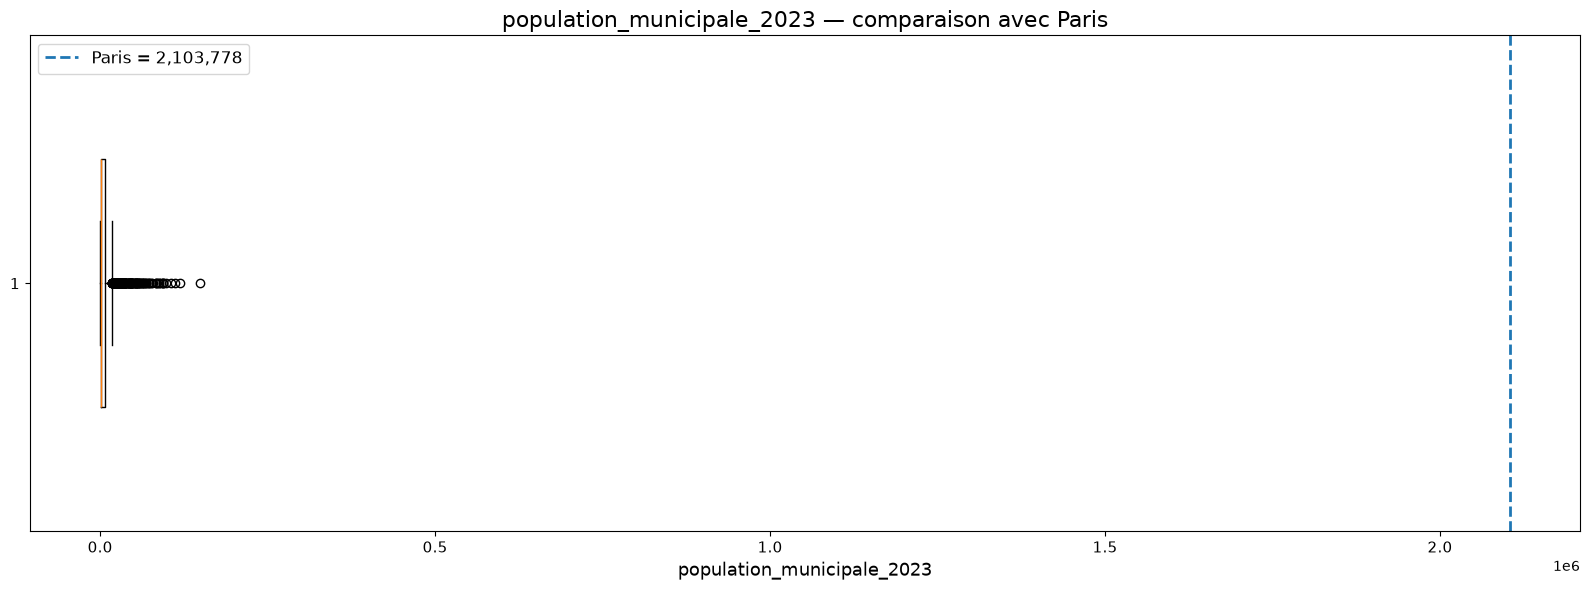

C:\Users\jessi\AppData\Local\Temp\ipykernel_62184\3656523147.py:51: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


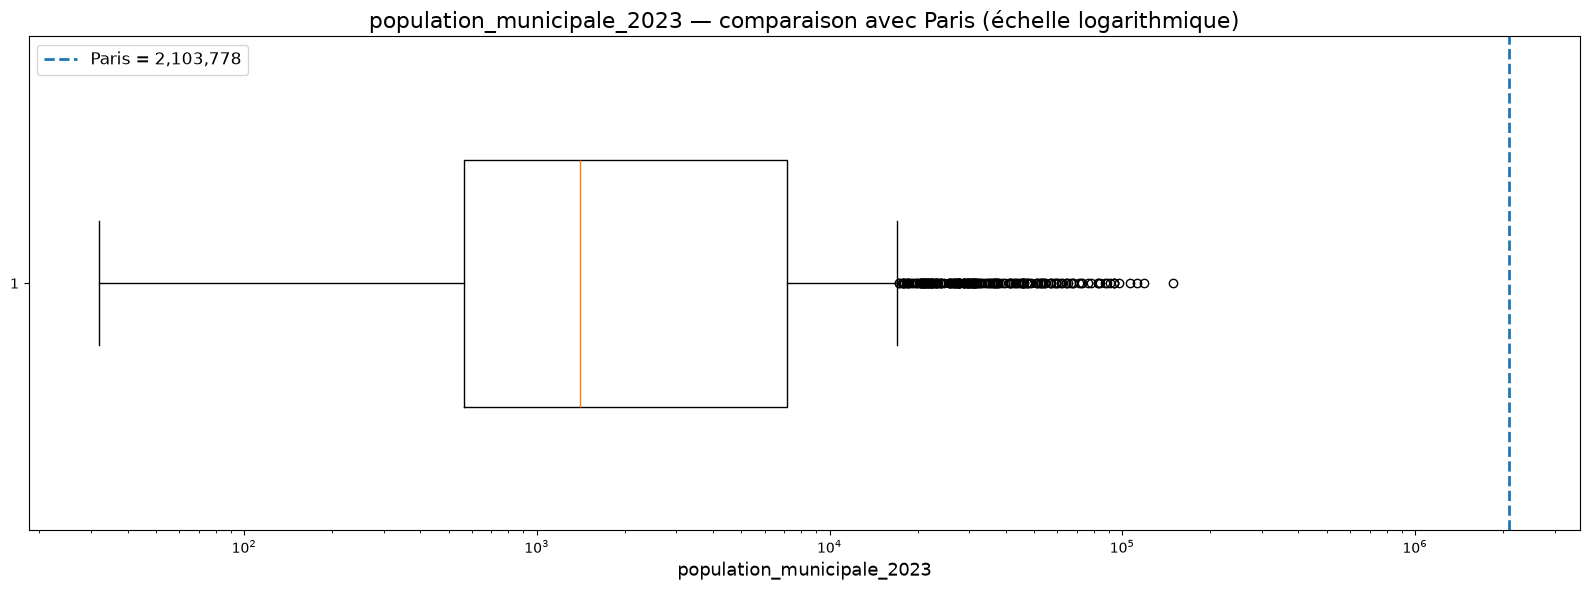

In [356]:
import matplotlib.pyplot as plt

col = "population_municipale_2023"

paris = df_modele.loc[
    df_modele["nom_commune"].str.upper() == "PARIS",
    col
].iloc[0]

autres_communes = df_modele.loc[
    df_modele["nom_commune"].str.upper() != "PARIS",
    col
].dropna()

plt.figure(figsize=(16, 6))

plt.boxplot(
    autres_communes,
    vert=False,
    widths=0.5
)

plt.axvline(
    paris,
    linestyle="--",
    linewidth=2,
    label=f"Paris = {paris:,.0f}"
)

plt.title(
    f"{col} — comparaison avec Paris",
    fontsize=16
)

plt.xlabel(
    col,
    fontsize=13
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 6))

plt.boxplot(
    autres_communes,
    vert=False,
    widths=0.5
)

plt.axvline(
    paris,
    linestyle="--",
    linewidth=2,
    label=f"Paris = {paris:,.0f}"
)

plt.xscale("log")

plt.title(
    f"{col} — comparaison avec Paris (échelle logarithmique)",
    fontsize=16
)

plt.xlabel(col, fontsize=13)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

doublons commune/année ;
valeurs manquantes ;
valeurs aberrantes ;
types de données ;
variables constantes ;
variables fortement corrélées ;
cohérence des années ;
cohérence géographique ;
distribution de la cible.

In [357]:
df_model2 = df_modele.copy()

Commune A
│
├── population historique
├── démographie
├── revenus
├── chômage
├── logements
├── évolution population
├── évolution revenus
├── variables 2024
└── infrastructures non commerciales 2025
          │
          ▼
      MODÈLE UNIQUE
          │
          ├── Y1 → potentiel banque
          ├── Y2 → potentiel restauration rapide
          ├── Y3 → potentiel supermarché
          ├── Y4 → potentiel boulangerie
          ├── ...
          └── Yn → potentiel librairie

MultiOutputRegressor(XGBRegressor(...))

In [358]:
#### Création de la variable cible
variables_cibles = [
    "banque_2025",
    "restauration_rapide_2025",
    "hypermarche_grand_magasin_2025",
    "supermarche_2025",
    "superette_2025",
    "epicerie_2025",
    "boulangerie_patisserie_2025",
    "magasin_vetements_2025",
    "magasin_chaussures_2025",
    "magasin_meubles_2025",
    "parfumerie_cosmetique_2025",
    "electromenager_audio_video_informatique_2025",
    "librairie_2025",
    "papeterie_presse_2025"
]

In [359]:
df_model2[variables_cibles].describe().T

,count,mean,std,min,25%,50%,75%,max
banque_2025,1266.0,3.222749,35.883928,0.0,0.0,0.0,2.0,1265.0
restauration_rapide_2025,1266.0,39.018167,589.702860,0.0,1.0,3.0,15.0,20911.0
hypermarche_grand_magasin_2025,1266.0,0.214850,1.334125,0.0,0.0,0.0,0.0,44.0
supermarche_2025,1266.0,1.883886,20.284380,0.0,0.0,0.0,1.0,715.0
superette_2025,1266.0,0.921011,10.495853,0.0,0.0,0.0,0.0,368.0
epicerie_2025,1266.0,5.564771,59.994500,0.0,0.0,1.0,2.0,2106.0
boulangerie_patisserie_2025,1266.0,6.667457,65.526225,0.0,0.0,1.0,4.0,2307.0
magasin_vetements_2025,1266.0,7.454186,133.711783,0.0,0.0,0.0,1.0,4743.0
magasin_chaussures_2025,1266.0,1.013428,18.868481,0.0,0.0,0.0,0.0,669.0
magasin_meubles_2025,1266.0,1.544234,21.273079,0.0,0.0,0.0,1.0,751.0


In [360]:
df_model2[variables_cibles].nunique()

banque_2025                                      35
restauration_rapide_2025                        161
hypermarche_grand_magasin_2025                    6
supermarche_2025                                 23
superette_2025                                   17
epicerie_2025                                    54
boulangerie_patisserie_2025                      60
magasin_vetements_2025                           63
magasin_chaussures_2025                          18
magasin_meubles_2025                             23
parfumerie_cosmetique_2025                       24
electromenager_audio_video_informatique_2025     21
librairie_2025                                   12
papeterie_presse_2025                            19
dtype: int64

In [361]:
(df_model2[variables_cibles] == 0).mean().sort_values(ascending=False)

hypermarche_grand_magasin_2025                  0.864139
magasin_chaussures_2025                         0.848341
librairie_2025                                  0.813586
papeterie_presse_2025                           0.786730
superette_2025                                  0.785150
parfumerie_cosmetique_2025                      0.751185
magasin_meubles_2025                            0.744866
electromenager_audio_video_informatique_2025    0.703791
banque_2025                                     0.695893
magasin_vetements_2025                          0.656398
supermarche_2025                                0.636651
epicerie_2025                                   0.465245
boulangerie_patisserie_2025                     0.375197
restauration_rapide_2025                        0.203791
dtype: float64

In [362]:
variables_infrastructures_contextuelles = [
    "bureau_de_poste_2025",
    "ecole_maternelle_2025",
    "ecole_primaire_2025",
    "ecole_elementaire_2025",
    "college_2025",
    "lycee_2025",
    "urgences_2025",
    "pharmacie_2025",
    "gare_nationale_2025",
    "gare_regionale_2025",
    "transport_ferroviaire_local_rer_metro_transilien_2025",
    "salle_non_specialisee_sport_2025",
    "bowling_2025",
    "salle_remise_en_forme_2025",
    "gymnase_multisports_2025"
]

In [363]:
resume_y = pd.DataFrame({
    "nb_lignes": df[variables_cibles].count(),
    "nb_nan": df[variables_cibles].isna().sum(),
    "pct_nan": df[variables_cibles].isna().mean() * 100,
    "nb_zero": (df[variables_cibles] == 0).sum(),
    "pct_zero": (df[variables_cibles] == 0).mean() * 100,
    "nb_positif": (df[variables_cibles] > 0).sum(),
    "pct_positif": (df[variables_cibles] > 0).mean() * 100,
    "moyenne": df[variables_cibles].mean(),
    "mediane": df[variables_cibles].median(),
    "maximum": df[variables_cibles].max()
}).sort_values("pct_positif", ascending=False)

display(resume_y)

,nb_lignes,nb_nan,pct_nan,nb_zero,pct_zero,nb_positif,pct_positif,moyenne,mediane,maximum
restauration_rapide_2025,1266,0,0.0,258,20.379147,1008,79.620853,39.018167,3.0,20911.0
boulangerie_patisserie_2025,1266,0,0.0,475,37.519747,791,62.480253,6.667457,1.0,2307.0
epicerie_2025,1266,0,0.0,589,46.524487,677,53.475513,5.564771,1.0,2106.0
supermarche_2025,1266,0,0.0,806,63.665087,460,36.334913,1.883886,0.0,715.0
magasin_vetements_2025,1266,0,0.0,831,65.639810,435,34.360190,7.454186,0.0,4743.0
banque_2025,1266,0,0.0,881,69.589258,385,30.410742,3.222749,0.0,1265.0
electromenager_audio_video_informatique_2025,1266,0,0.0,891,70.379147,375,29.620853,1.607425,0.0,862.0
magasin_meubles_2025,1266,0,0.0,943,74.486572,323,25.513428,1.544234,0.0,751.0
parfumerie_cosmetique_2025,1266,0,0.0,951,75.118483,315,24.881517,2.060821,0.0,1328.0
superette_2025,1266,0,0.0,994,78.515008,272,21.484992,0.921011,0.0,368.0


### Rester sur une target unique : restauration rapide car elle est plus présente
y = restauration_rapide_2025

In [364]:
df_model2[
    ["code_commune", "nom_commune", "restauration_rapide_2025"]
].sort_values(
    "restauration_rapide_2025",
    ascending=False
).head(10)

,code_commune,nom_commune,restauration_rapide_2025
0,75056,Paris,20911.0
1027,93066,Saint-Denis,598.0
965,92012,Boulogne-Billancourt,564.0
1016,93048,Montreuil,534.0
979,92044,Levallois-Perret,463.0
997,93001,Aubervilliers,368.0
754,78646,Versailles,352.0
1053,94041,Ivry-sur-Seine,345.0
987,92062,Puteaux,335.0
1088,95018,Argenteuil,330.0


In [365]:
df_model2["restauration_rapide_2025"].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
)

count     1266.000000
mean        39.018167
std        589.702860
min          0.000000
25%          1.000000
50%          3.000000
75%         15.000000
90%         65.000000
95%        113.250000
99%        307.050000
max      20911.000000
Name: restauration_rapide_2025, dtype: float64

In [366]:
#Exclure les variables commerciales

variables_commerciales_2025 = [
    "banque_2025",
    "restauration_rapide_2025",
    "hypermarche_grand_magasin_2025",
    "supermarche_2025",
    "superette_2025",
    "epicerie_2025",
    "boulangerie_patisserie_2025",
    "magasin_vetements_2025",
    "magasin_chaussures_2025",
    "magasin_meubles_2025",
    "parfumerie_cosmetique_2025",
    "electromenager_audio_video_informatique_2025",
    "librairie_2025",
    "papeterie_presse_2025",
    "bureau_de_poste_2025",
    "ecole_maternelle_2025",
    "ecole_primaire_2025",
    "ecole_elementaire_2025",
    "college_2025",
    "lycee_2025",
    "urgences_2025",
    "pharmacie_2025",
    "gare_nationale_2025",
    "gare_regionale_2025",
    "transport_ferroviaire_local_rer_metro_transilien_2025",
    "salle_non_specialisee_sport_2025",
    "bowling_2025",
    "salle_remise_en_forme_2025",
    "gymnase_multisports_2025"
]


In [367]:
colonnes_identifiantes = [
    "code_commune",
    "nom_commune"
]

colonnes_exclues = (
    colonnes_identifiantes
    + variables_commerciales_2025
)

variables_X = [
    col for col in df.columns
    if col not in colonnes_exclues
]

X = df_model2[variables_X].copy()
y = df_model2["restauration_rapide_2025"].copy()
target = y.copy()

In [368]:
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nNombre de variables explicatives :", X.shape[1])

print("\nTypes de variables :")
print(X.dtypes.value_counts())

Dimensions de X : (1266, 127)
Dimensions de y : (1266,)

Nombre de variables explicatives : 127

Types de variables :
float64    116
int64       11
Name: count, dtype: int64


In [369]:
print("\nVariables 2025 présentes dans X :")
print([
    col for col in X.columns
    if col.endswith("_2025")
])


Variables 2025 présentes dans X :
[]


In [370]:
# audit_nan_non_nuls = audit_nan[
#     audit_nan["nb_nan"] > 0
# ]

# print(
#     "Nombre de variables contenant au moins un NaN :",
#     len(audit_nan_non_nuls)
# )

# audit_nan_non_nuls

In [371]:
# Valeurs aberrantes
resume_X = X.describe().T

resume_X["IQR"] = (
    resume_X["75%"] - resume_X["25%"]
)

resume_X["borne_basse"] = (
    resume_X["25%"] - 1.5 * resume_X["IQR"]
)

resume_X["borne_haute"] = (
    resume_X["75%"] + 1.5 * resume_X["IQR"]
)

resume_X["nb_outliers"] = (
    (X.lt(resume_X["borne_basse"], axis=1)) |
    (X.gt(resume_X["borne_haute"], axis=1))
).sum()

resume_X["pct_outliers"] = (
    resume_X["nb_outliers"] / len(X) * 100
)

resume_X.sort_values(
    "pct_outliers",
    ascending=False
).head(30)

,count,mean,std,min,25%,50%,75%,max,IQR,borne_basse,borne_haute,nb_outliers,pct_outliers
taux_pauvrete_60_2023,1266.0,11.680648,5.510408,3.00000,10.400000,10.400000,10.400000,45.40000,0.000000,10.400000,10.400000,541,42.733017
logements_moins_2_ans_delta_2017_2023,1266.0,2.043037,164.781567,-4475.72767,-9.998495,-0.755210,9.165790,1067.96914,19.164285,-38.744923,37.912217,322,25.434439
logements_1_piece_delta_2017_2023,1266.0,37.259148,179.049742,-1236.62585,-1.666645,0.000000,6.000000,2018.61062,7.666645,-13.166613,17.499968,315,24.881517
population_femmes_25_39_ans_delta_2017_2023,1266.0,12.702558,349.877806,-10903.46520,-6.944910,3.000000,19.970390,1742.04617,26.915300,-47.317860,60.343340,299,23.617694
population_femmes_moins_de_15_ans_delta_2017_2023,1266.0,-21.284818,499.129032,-16932.56324,-16.038505,-1.353260,14.059290,861.47763,30.097795,-61.185197,59.205982,290,22.906793
travaille_dans_la_commune_delta_2017_2023,1266.0,-13.619611,614.340581,-21390.01137,-25.169667,-6.000000,5.000000,1301.05283,30.169667,-70.424169,50.254501,283,22.353870
population_hommes_moins_de_15_ans_delta_2017_2023,1266.0,-20.956986,522.815888,-17820.36536,-16.185345,-1.837750,13.946312,977.73414,30.131657,-61.382831,59.143799,282,22.274882
logements_4_pieces_delta_2017_2023,1266.0,10.661456,122.483149,-2148.10388,-7.067897,1.000000,14.250385,1245.32156,21.318283,-39.045321,46.227809,278,21.958926
population_femmes_40_54_ans_delta_2017_2023,1266.0,-1.229192,533.674996,-18586.84698,-13.515420,-2.076035,11.933910,1214.61567,25.449330,-51.689415,50.107905,277,21.879937
population_hommes_40_54_ans_delta_2017_2023,1266.0,-1.170336,484.520476,-16836.58972,-14.230073,-3.000000,10.853090,795.15832,25.083163,-51.854816,48.477834,274,21.642970


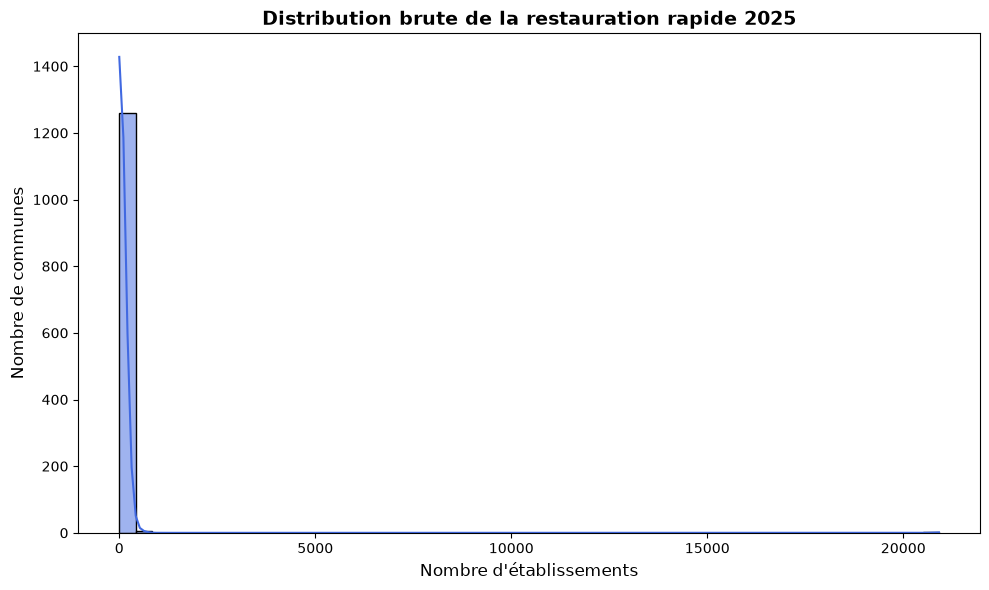

In [372]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "restauration_rapide_2025"

# Configuration de la figure unique
plt.figure(figsize=(10, 6))

# Histogramme + courbe de densité
sns.histplot(
    df[target],
    bins=50,
    kde=True,
    color="royalblue"
)

# Titres et labels
plt.title(
    "Distribution brute de la restauration rapide 2025",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(
    "Nombre d'établissements",
    fontsize=12
)
plt.ylabel(
    "Nombre de communes",
    fontsize=12
)

plt.tight_layout()
plt.show()

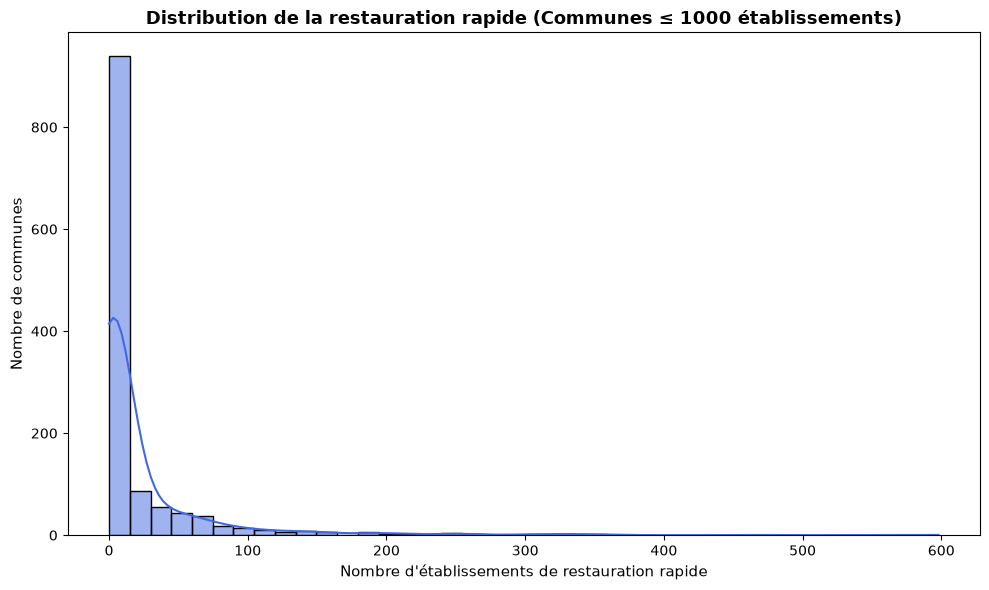

In [373]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Filtrage pour exclure les quelques valeurs extrêmes
filtre_zoom = df_model2[target] <= 1000
sns.histplot(df_model2.loc[filtre_zoom, target], bins=40, kde=True, color="royalblue")

plt.title("Distribution de la restauration rapide (Communes ≤ 1000 établissements)", fontsize=13, fontweight="bold")
plt.xlabel("Nombre d'établissements de restauration rapide", fontsize=11)
plt.ylabel("Nombre de communes", fontsize=11)

plt.tight_layout()
plt.show()

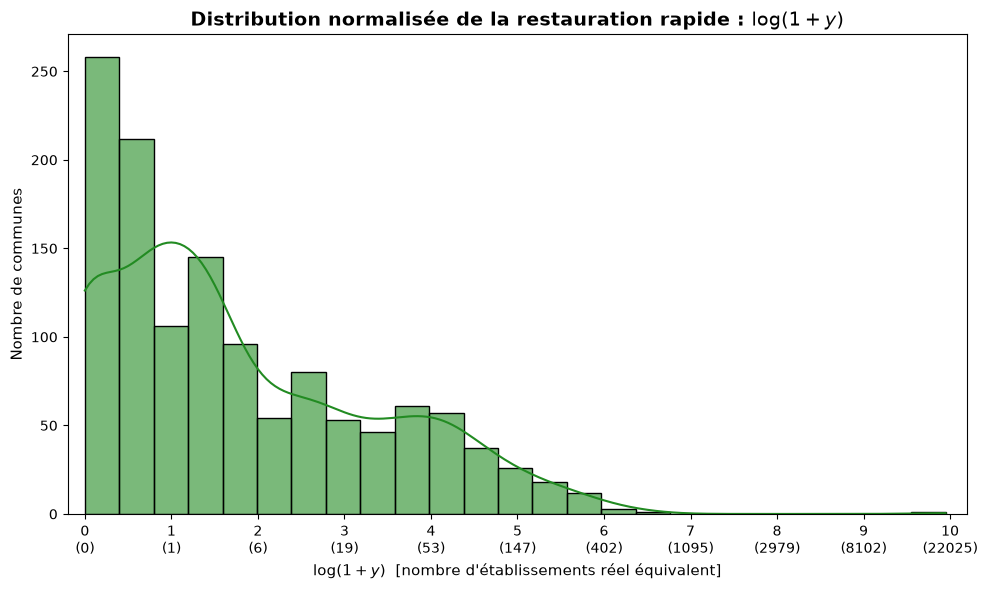

In [374]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(10, 6))

# Calcul du log(1 + y)
log_y = np.log1p(df_model2[target])

# Histogramme et KDE
sns.histplot(
    log_y,
    bins=25,
    kde=True,
    color="forestgreen",
    edgecolor="black",
    alpha=0.6,
)

# Graduations avec valeur log et équivalent réel entre parenthèses
custom_ticks = list(range(11))
tick_labels = [f"{t}\n({int(np.expm1(t))})" for t in custom_ticks]

plt.xticks(custom_ticks, tick_labels)
plt.xlim(-0.2, 10.2)

plt.title(
    "Distribution normalisée de la restauration rapide : $\\log(1 + y)$",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel(
    "$\\log(1 + y)$  [nombre d'établissements réel équivalent]", fontsize=11
)
plt.ylabel("Nombre de communes", fontsize=11)

plt.tight_layout()
plt.show()


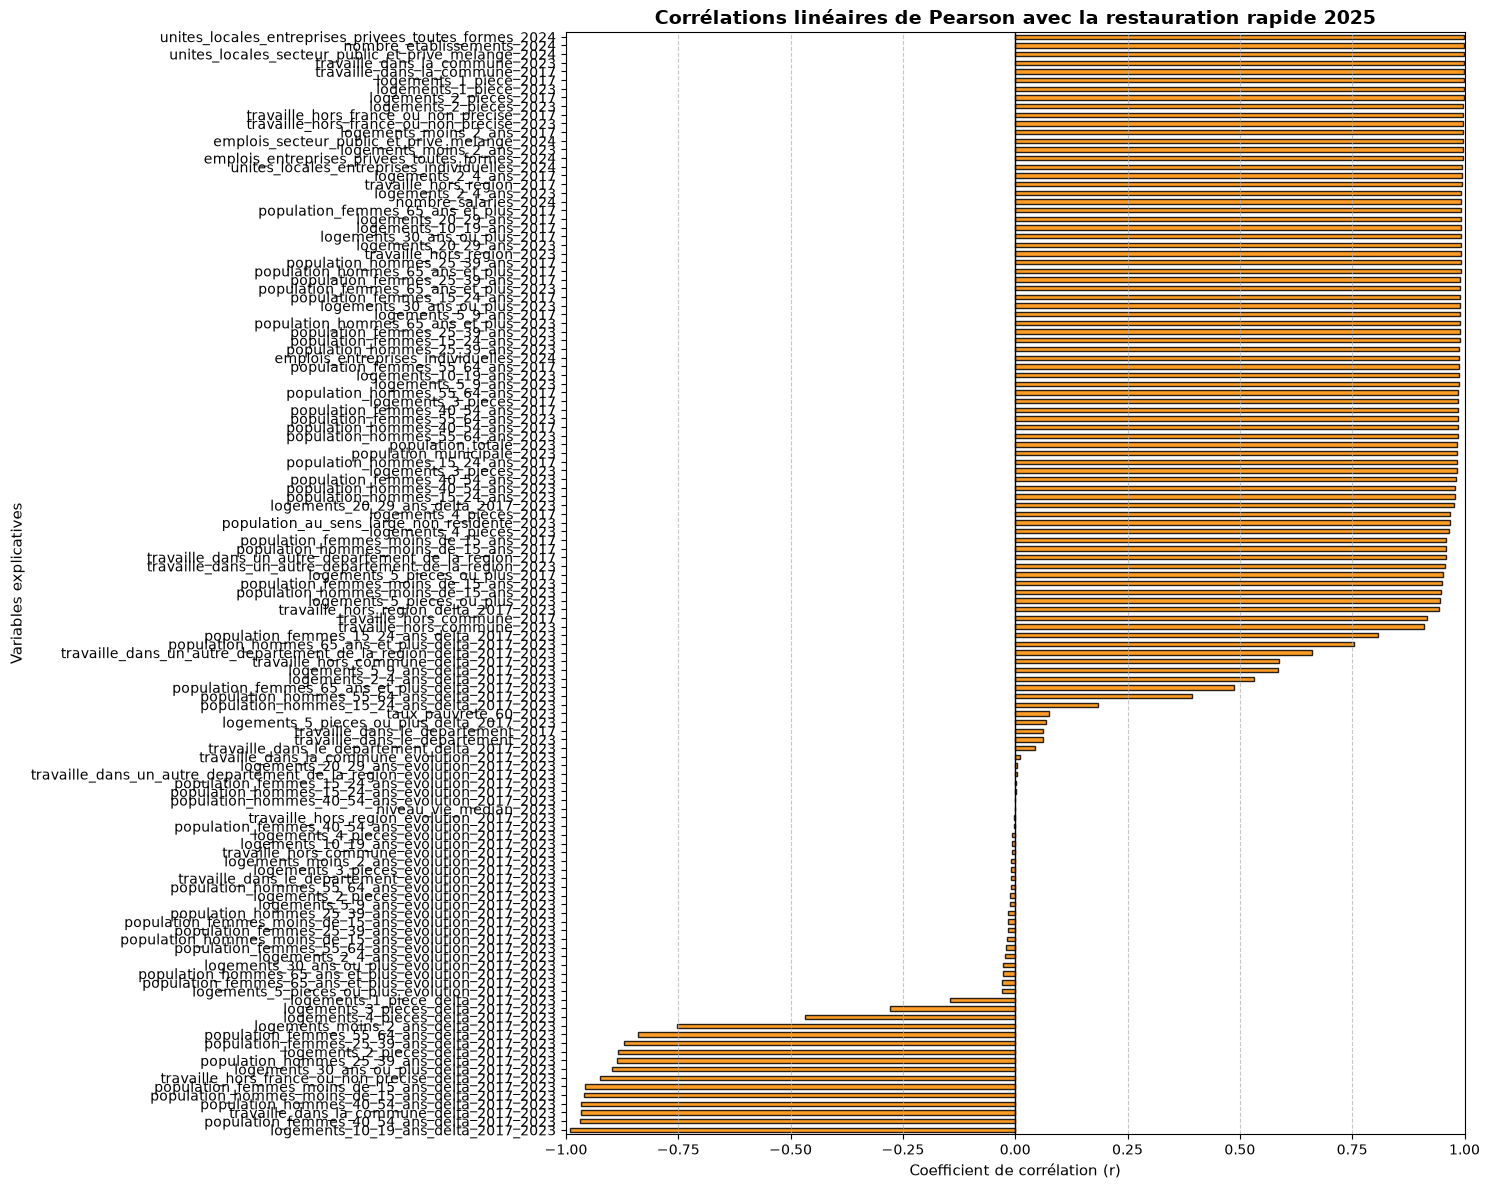

In [375]:
import matplotlib.pyplot as plt

# Variables numériques
variables_num = X.select_dtypes(include="number").columns

# Corrélations de Pearson avec la cible
corrs = X[variables_num].corrwith(y).sort_values()

# Graphique
plt.figure(figsize=(15, 12))

corrs.plot(
    kind="barh",
    color="darkorange",
    edgecolor="black",
    alpha=0.85
)

plt.title(
    "Corrélations linéaires de Pearson avec la restauration rapide 2025",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Coefficient de corrélation (r)", fontsize=11)
plt.ylabel("Variables explicatives", fontsize=11)

plt.xlim(-1, 1)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

In [376]:
print("Target dans X :", target in X.columns)
print(X.shape)
print(y.shape)

print("\nTOP 20 POSITIVES")
print(corrs.sort_values(ascending=False).head(20))

print("\nTOP 20 NEGATIVES")
print(corrs.sort_values().head(20))

Target dans X : False
(1266, 127)
(1266,)

TOP 20 POSITIVES
unites_locales_entreprises_privees_toutes_formes_2024    0.999653
nombre_etablissements_2024                               0.999648
unites_locales_secteur_public_et_prive_melange_2024      0.999638
travaille_dans_la_commune_2023                           0.999557
travaille_dans_la_commune_2017                           0.999488
logements_1_piece_2017                                   0.999347
logements_1_piece_2023                                   0.999107
logements_2_pieces_2017                                  0.998128
logements_2_pieces_2023                                  0.997323
travaille_hors_france_ou_non_precise_2017                0.997280
travaille_hors_france_ou_non_precise_2023                0.997258
logements_moins_2_ans_2017                               0.996939
emplois_secteur_public_et_prive_melange_2024             0.996273
logements_moins_2_ans_2023                               0.996247
emplois_entrepri

In [377]:
# Correlation des variables avec la cible

import numpy as np

variables_num = X.select_dtypes(include="number").columns

corr_brute = X[variables_num].corrwith(y)

corr_log = X[variables_num].corrwith(
    np.log1p(y)
)

comparaison_corr = pd.DataFrame({
    "Pearson_brut": corr_brute,
    "Pearson_log": corr_log
})

comparaison_corr["variation"] = (
    comparaison_corr["Pearson_log"]
    - comparaison_corr["Pearson_brut"]
)

comparaison_corr = comparaison_corr.sort_values(
    "Pearson_log",
    ascending=False
)

comparaison_corr.head(30)

,Pearson_brut,Pearson_log,variation
travaille_dans_le_departement_2017,0.061370,0.788671,0.727301
travaille_dans_le_departement_2023,0.061170,0.787059,0.725889
population_femmes_65_ans_et_plus_delta_2017_2023,0.487018,0.604606,0.117588
logements_5_9_ans_delta_2017_2023,0.583962,0.595514,0.011552
travaille_hors_commune_delta_2017_2023,0.586158,0.588176,0.002018
travaille_dans_le_departement_delta_2017_2023,0.044069,0.574344,0.530275
population_hommes_55_64_ans_delta_2017_2023,0.393580,0.552769,0.159189
population_hommes_15_24_ans_delta_2017_2023,0.183595,0.531634,0.348039
logements_5_pieces_ou_plus_delta_2017_2023,0.069042,0.528898,0.459855
population_hommes_65_ans_et_plus_delta_2017_2023,0.755089,0.525827,-0.229262


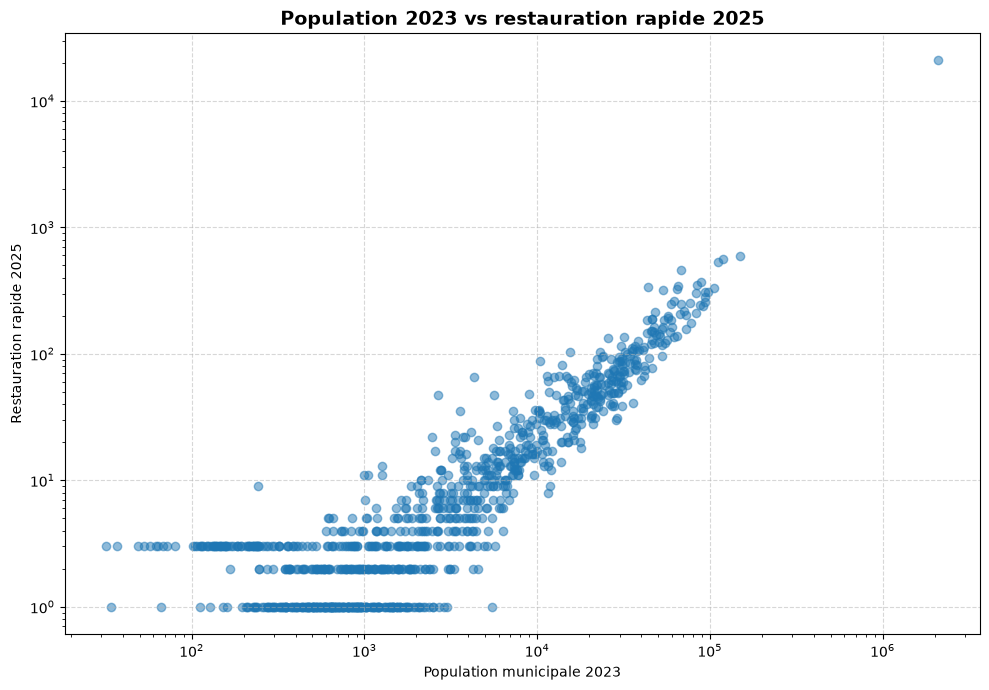

In [378]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["population_municipale_2023"],
    y,
    alpha=0.5
)

plt.xlabel("Population municipale 2023")
plt.ylabel("Restauration rapide 2025")

plt.title(
    "Population 2023 vs restauration rapide 2025",
    fontsize=14,
    fontweight="bold"
)

plt.xscale("log")
plt.yscale("log")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

#### Colinarité entre les variables

In [379]:
SEUIL_CORR = 0.99

corr_X = X.select_dtypes(include="number").corr().abs()

upper = corr_X.where(
    np.triu(
        np.ones(corr_X.shape),
        k=1
    ).astype(bool)
)

paires_fortes = (
    upper
    .stack()
    .reset_index()
)

paires_fortes.columns = [
    "variable_1",
    "variable_2",
    "correlation"
]

paires_fortes = (
    paires_fortes[
        paires_fortes["correlation"] >= SEUIL_CORR
    ]
    .sort_values("correlation", ascending=False)
)

print(f"Nombre de paires avec |r| >= {SEUIL_CORR} : {len(paires_fortes)}")

paires_fortes.head(50)

Nombre de paires avec |r| >= 0.99 : 1309


,variable_1,variable_2,correlation
7553,population_municipale_2023,population_totale_2023,0.999999
8577,unites_locales_secteur_public_et_prive_melange...,unites_locales_entreprises_privees_toutes_form...,0.999997
2817,travaille_dans_la_commune_2017,travaille_dans_la_commune_2023,0.999972
8706,unites_locales_entreprises_privees_toutes_form...,nombre_etablissements_2024,0.999890
5644,population_femmes_moins_de_15_ans_2017,population_hommes_moins_de_15_ans_2017,0.999888
8579,unites_locales_secteur_public_et_prive_melange...,nombre_etablissements_2024,0.999876
5772,population_femmes_moins_de_15_ans_2023,population_hommes_moins_de_15_ans_2023,0.999854
4620,population_femmes_25_39_ans_2017,population_hommes_25_39_ans_2017,0.999848
1025,logements_2_pieces_2017,logements_2_pieces_2023,0.999839
5,logements_10_19_ans_2017,logements_20_29_ans_2023,0.999803


In [380]:
variables_redundantes = pd.unique(
    paires_fortes[
        ["variable_1", "variable_2"]
    ].values.ravel()
)

print("Nombre de variables concernées :", len(variables_redundantes))

Nombre de variables concernées : 70


In [381]:
# ============================================
# 1. SUPPRESSION DES VARIABLES 2017
# ============================================

cols_2017 = [
    col for col in X.columns
    if col.endswith("_2017")
]

X1 = X.drop(columns=cols_2017)


# ============================================
# 3. CRÉATION DES PARTS DÉMOGRAPHIQUES
# ============================================

population_ref = "population_municipale_2023"

cols_population = [
    col for col in X1.columns
    if col.startswith("population_")
    and col.endswith("_2023")
    and col != population_ref
]

for col in cols_population:

    nom_part = col.replace(
        "population_",
        "part_population_"
    )

    X1[nom_part] = np.where(
        X1[population_ref] > 0,
        X1[col] / X1[population_ref],
        np.nan
    )


# ============================================
# 4. PARTS PAR TRANCHE D'ÂGE
# ============================================

ages = [
    "moins_de_15_ans",
    "15_24_ans",
    "25_39_ans",
    "40_54_ans",
    "55_64_ans",
    "65_ans_et_plus"
]

for age in ages:

    col_f = f"population_femmes_{age}_2023"
    col_h = f"population_hommes_{age}_2023"

    if col_f in X.columns and col_h in X.columns:

        col_total = f"population_{age}_2023"
        col_part = f"part_population_{age}_2023"

        X1[col_total] = X1[col_f] + X1[col_h]

        X1[col_part] = np.where(
            X1[population_ref] > 0,
            X1[col_total] / X1[population_ref],
            np.nan
        )


# ============================================
# 5. PARTS DES LOGEMENTS
# ============================================

logements_ref = "logements_total_2023"

if logements_ref in X1.columns:

    cols_logements = [
        col for col in X1.columns
        if col.startswith("logements_")
        and col.endswith("_2023")
        and col != logements_ref
    ]

    for col in cols_logements:

        nom_part = col.replace(
            "logements_",
            "part_logements_"
        )

        X1[nom_part] = np.where(
            X1[logements_ref] > 0,
            X1[col] / X1[logements_ref],
            np.nan
        )


# ============================================
# 6. VÉRIFICATION
# ============================================

print("Dimension finale de X :", X1.shape)

print("\nVariables 2017 restantes :")
print([
    col for col in X1.columns
    if col.endswith("_2017")
])

print("\nVariables de parts créées :")
print([
    col for col in X.columns
    if col.startswith("part_")
])

Dimension finale de X : (1266, 148)

Variables 2017 restantes :
[]

Variables de parts créées :
[]


In [382]:
# ============================================================
# SUPPRESSION DES VARIABLES SOURCES APRÈS CRÉATION DES PARTS
# ============================================================

# Population : uniquement les variables sources 2023
cols_population_sources = [
    col for col in X1.columns
    if (
        (col.startswith("population_femmes_") or
         col.startswith("population_hommes_"))
        and col.endswith("_2023")
        and "_delta_" not in col
        and "_evolution_" not in col
    )
]

# Logement : uniquement les variables sources 2023
cols_logements_sources = [
    col for col in X1.columns
    if (
        col.startswith("logements_")
        and col.endswith("_2023")
        and "_delta_" not in col
        and "_evolution_" not in col
    )
]

cols_a_supprimer = cols_population_sources + cols_logements_sources

print("Colonnes supprimées :")
for col in cols_a_supprimer:
    print(col)


Colonnes supprimées :
population_femmes_15_24_ans_2023
population_femmes_25_39_ans_2023
population_femmes_40_54_ans_2023
population_femmes_55_64_ans_2023
population_femmes_65_ans_et_plus_2023
population_femmes_moins_de_15_ans_2023
population_hommes_15_24_ans_2023
population_hommes_25_39_ans_2023
population_hommes_40_54_ans_2023
population_hommes_55_64_ans_2023
population_hommes_65_ans_et_plus_2023
population_hommes_moins_de_15_ans_2023
logements_10_19_ans_2023
logements_1_piece_2023
logements_20_29_ans_2023
logements_2_4_ans_2023
logements_2_pieces_2023
logements_30_ans_ou_plus_2023
logements_3_pieces_2023
logements_4_pieces_2023
logements_5_9_ans_2023
logements_5_pieces_ou_plus_2023
logements_moins_2_ans_2023


In [383]:
# ============================================================
# SUPPRESSION DE TOUTES LES SOURCES POPULATION 2023
# ============================================================

population_ref = "population_municipale_2023"

cols_population_sources = [
    col for col in X1.columns
    if (
        col.startswith("population_")
        and col.endswith("_2023")
        and col != population_ref
        and "_delta_" not in col
        and "_evolution_" not in col
    )
]

print("Variables population sources supprimées :")
for col in cols_population_sources:
    print(col)

X2 = X1.drop(columns=cols_population_sources)

print("\nNombre de colonnes supprimées :", len(cols_population_sources))
print("Dimension de X2 :", X2.shape)

Variables population sources supprimées :
population_femmes_15_24_ans_2023
population_femmes_25_39_ans_2023
population_femmes_40_54_ans_2023
population_femmes_55_64_ans_2023
population_femmes_65_ans_et_plus_2023
population_femmes_moins_de_15_ans_2023
population_hommes_15_24_ans_2023
population_hommes_25_39_ans_2023
population_hommes_40_54_ans_2023
population_hommes_55_64_ans_2023
population_hommes_65_ans_et_plus_2023
population_hommes_moins_de_15_ans_2023
population_au_sens_large_non_residente_2023
population_totale_2023
population_moins_de_15_ans_2023
population_15_24_ans_2023
population_25_39_ans_2023
population_40_54_ans_2023
population_55_64_ans_2023
population_65_ans_et_plus_2023

Nombre de colonnes supprimées : 20
Dimension de X2 : (1266, 128)


In [384]:
# Vérifier les sources population restantes
print("\nSources population 2023 restantes :")
print([
    col for col in X2.columns
    if (
        (col.startswith("population_femmes_") or
         col.startswith("population_hommes_"))
        and col.endswith("_2023")
    )
    and "_delta_" not in col
    and "_evolution_" not in col
])


Sources population 2023 restantes :
[]


In [385]:
# ============================================================
# SUPPRESSION DES SOURCES LOGEMENT 2023
# ============================================================

logements_ref = "logements_total_2023"

cols_logements_sources = [
    col for col in X2.columns
    if (
        col.startswith("logements_")
        and col.endswith("_2023")
        and col != logements_ref
        and "_delta_" not in col
        and "_evolution_" not in col
    )
]

print("Colonnes logements sources supprimées :")
for col in cols_logements_sources:
    print(col)

X2 = X2.drop(columns=cols_logements_sources)

print("\nNombre supprimé :", len(cols_logements_sources))
print("Nouvelle dimension :", X2.shape)

Colonnes logements sources supprimées :
logements_10_19_ans_2023
logements_1_piece_2023
logements_20_29_ans_2023
logements_2_4_ans_2023
logements_2_pieces_2023
logements_30_ans_ou_plus_2023
logements_3_pieces_2023
logements_4_pieces_2023
logements_5_9_ans_2023
logements_5_pieces_ou_plus_2023
logements_moins_2_ans_2023

Nombre supprimé : 11
Nouvelle dimension : (1266, 117)


In [386]:
X2 = X2.drop(
    columns=[
        "part_population_totale_2023",
        "part_population_au_sens_large_non_residente_2023"
    ],
    errors="ignore"
)

In [387]:
# ============================================================
# NOUVELLE ANALYSE DE LA MULTICOLINÉARITÉ
# ============================================================

import numpy as np
import pandas as pd

X2_num = X2.select_dtypes(include="number")

corr_X2 = X2_num.corr().abs()

# Triangle supérieur uniquement
upper = corr_X2.where(
    np.triu(np.ones(corr_X2.shape), k=1).astype(bool)
)

paires_fortes = (
    upper
    .stack()
    .reset_index()
)

paires_fortes.columns = [
    "variable_1",
    "variable_2",
    "correlation"
]

paires_fortes = paires_fortes.sort_values(
    "correlation",
    ascending=False
)

print("Nombre de variables numériques :", X2_num.shape[1])
print("\nTop 30 des corrélations entre variables explicatives :")

paires_fortes.head(30)

Nombre de variables numériques : 115

Top 30 des corrélations entre variables explicatives :


,variable_1,variable_2,correlation
1509,unites_locales_secteur_public_et_prive_melange...,unites_locales_entreprises_privees_toutes_form...,0.999997
1626,unites_locales_entreprises_privees_toutes_form...,nombre_etablissements_2024,0.999890
1511,unites_locales_secteur_public_et_prive_melange...,nombre_etablissements_2024,0.999876
16,travaille_dans_la_commune_2023,nombre_etablissements_2024,0.999320
14,travaille_dans_la_commune_2023,unites_locales_entreprises_privees_toutes_form...,0.999306
13,travaille_dans_la_commune_2023,unites_locales_secteur_public_et_prive_melange...,0.999300
1161,emplois_secteur_public_et_prive_melange_2024,emplois_entreprises_privees_toutes_formes_2024,0.999162
476,travaille_hors_france_ou_non_precise_2023,nombre_etablissements_2024,0.998097
1280,emplois_entreprises_privees_toutes_formes_2024,nombre_salaries_2024,0.997909
474,travaille_hors_france_ou_non_precise_2023,unites_locales_entreprises_privees_toutes_form...,0.997858


In [388]:
cols_economie = [
    c for c in X2.columns
    if (
        "_2024" in c
        or "_2023" in c
    )
    and any(
        mot in c.lower()
        for mot in [
            "unites",
            "etablissements",
            "emplois",
            "salaries",
            "travaille"
        ]
    )
]

print("=== VARIABLES ÉCONOMIQUES ===")

for i, c in enumerate(cols_economie, start=1):
    print(f"{i}. {c}")

print("\nNombre :", len(cols_economie))

=== VARIABLES ÉCONOMIQUES ===
1. travaille_dans_la_commune_2023
2. travaille_dans_le_departement_2023
3. travaille_dans_un_autre_departement_de_la_region_2023
4. travaille_hors_commune_2023
5. travaille_hors_france_ou_non_precise_2023
6. travaille_hors_region_2023
7. emplois_entreprises_individuelles_2024
8. emplois_secteur_public_et_prive_melange_2024
9. emplois_entreprises_privees_toutes_formes_2024
10. unites_locales_entreprises_individuelles_2024
11. unites_locales_secteur_public_et_prive_melange_2024
12. unites_locales_entreprises_privees_toutes_formes_2024
13. nombre_salaries_2024
14. nombre_etablissements_2024
15. travaille_dans_la_commune_delta_2017_2023
16. travaille_dans_la_commune_evolution_2017_2023
17. travaille_dans_le_departement_delta_2017_2023
18. travaille_dans_le_departement_evolution_2017_2023
19. travaille_dans_un_autre_departement_de_la_region_delta_2017_2023
20. travaille_dans_un_autre_departement_de_la_region_evolution_2017_2023
21. travaille_hors_commune_delta_

In [389]:
cols_economie_a_supprimer = [
    # Unités locales redondantes
    "unites_locales_secteur_public_et_prive_melange_2024",
    "unites_locales_entreprises_privees_toutes_formes_2024",

    # Emploi redondant
    "emplois_secteur_public_et_prive_melange_2024",
    "nombre_salaries_2024",
    "emplois_entreprises_individuelles_2024",

    # Lieu de travail : niveaux redondants
    "travaille_dans_le_departement_2023",
    "travaille_dans_un_autre_departement_de_la_region_2023",
    "travaille_hors_commune_2023",
    "travaille_hors_france_ou_non_precise_2023",
    "travaille_hors_region_2023",

    # Évolutions/deltas des variables de lieu de travail
    "travaille_dans_le_departement_delta_2017_2023",
    "travaille_dans_le_departement_evolution_2017_2023",
    "travaille_dans_un_autre_departement_de_la_region_delta_2017_2023",
    "travaille_dans_un_autre_departement_de_la_region_evolution_2017_2023",
    "travaille_hors_commune_delta_2017_2023",
    "travaille_hors_commune_evolution_2017_2023",
    "travaille_hors_france_ou_non_precise_delta_2017_2023",
    "travaille_hors_region_delta_2017_2023",
    "travaille_hors_region_evolution_2017_2023"
]

X3 = X2.drop(
    columns=cols_economie_a_supprimer,
    errors="ignore"
)

print("Dimensions avant :", X2.shape)
print("Dimensions après :", X3.shape)

print("\nVariables économiques conservées :")
for c in X3.columns:
    if any(mot in c.lower() for mot in [
        "etablissements",
        "unites_locales",
        "emplois",
        "salaries",
        "travaille"
    ]):
        print(c)

Dimensions avant : (1266, 115)
Dimensions après : (1266, 96)

Variables économiques conservées :
travaille_dans_la_commune_2023
emplois_entreprises_privees_toutes_formes_2024
unites_locales_entreprises_individuelles_2024
nombre_etablissements_2024
travaille_dans_la_commune_delta_2017_2023
travaille_dans_la_commune_evolution_2017_2023


In [390]:
corr_X3 = (
    X3
    .select_dtypes(include="number")
    .corr()
    .abs()
)

upper = corr_X3.where(
    np.triu(np.ones(corr_X3.shape), k=1).astype(bool)
)

paires_fortes = (
    upper
    .stack()
    .reset_index()
)

paires_fortes.columns = [
    "variable_1",
    "variable_2",
    "correlation"
]

paires_fortes = paires_fortes.sort_values(
    "correlation",
    ascending=False
)

print(
    paires_fortes[
        paires_fortes["correlation"] >= 0.95
    ].to_string(index=False)
)

                                           variable_1                                             variable_2  correlation
                       travaille_dans_la_commune_2023                             nombre_etablissements_2024     0.999320
       emplois_entreprises_privees_toutes_formes_2024                             nombre_etablissements_2024     0.996627
        unites_locales_entreprises_individuelles_2024                             nombre_etablissements_2024     0.995525
                       travaille_dans_la_commune_2023         emplois_entreprises_privees_toutes_formes_2024     0.995464
                       travaille_dans_la_commune_2023          unites_locales_entreprises_individuelles_2024     0.995269
       emplois_entreprises_privees_toutes_formes_2024          unites_locales_entreprises_individuelles_2024     0.994580
                           population_municipale_2023          unites_locales_entreprises_individuelles_2024     0.992042
                       t

In [391]:
cols_economie_suppr = [
    "emplois_entreprises_privees_toutes_formes_2024",
    "unites_locales_entreprises_individuelles_2024",
    "travaille_dans_la_commune_2023",
    "travaille_dans_la_commune_delta_2017_2023",
    "travaille_dans_la_commune_evolution_2017_2023"
]

X4 = X3.drop(
    columns=cols_economie_suppr,
    errors="ignore"
)

In [392]:
# suppression des delta absolus
cols_delta = [
    c for c in X4.columns
    if "_delta_" in c
]

print("Nombre de deltas :", len(cols_delta))

for c in cols_delta:
    print(c)

Nombre de deltas : 35
logements_10_19_ans_delta_2017_2023
logements_1_piece_delta_2017_2023
logements_20_29_ans_delta_2017_2023
logements_2_4_ans_delta_2017_2023
logements_2_pieces_delta_2017_2023
logements_30_ans_ou_plus_delta_2017_2023
logements_3_pieces_delta_2017_2023
logements_4_pieces_delta_2017_2023
logements_5_9_ans_delta_2017_2023
logements_5_pieces_ou_plus_delta_2017_2023
logements_moins_2_ans_delta_2017_2023
population_femmes_15_24_ans_delta_2017_2023
population_femmes_25_39_ans_delta_2017_2023
population_femmes_40_54_ans_delta_2017_2023
population_femmes_55_64_ans_delta_2017_2023
population_femmes_65_ans_et_plus_delta_2017_2023
population_femmes_moins_de_15_ans_delta_2017_2023
population_hommes_15_24_ans_delta_2017_2023
population_hommes_25_39_ans_delta_2017_2023
population_hommes_40_54_ans_delta_2017_2023
population_hommes_55_64_ans_delta_2017_2023
population_hommes_65_ans_et_plus_delta_2017_2023
population_hommes_moins_de_15_ans_delta_2017_2023
part_population_femmes_15_2

In [393]:
# Supprimer uniquement les deltas absolus
cols_delta_absolus = [
    c for c in X4.columns
    if "_delta_" in c
    and not c.startswith("part_")
]

X5 = X4.drop(
    columns=cols_delta_absolus,
    errors="ignore"
)

print("=== DELTAS CONSERVÉS ===")

cols_delta_restants = [
    c for c in X5.columns
    if "_delta_" in c
]

for c in cols_delta_restants:
    print(c)

print("\nNombre de deltas restants :", len(cols_delta_restants))
print("Dimensions finales :", X5.shape)

=== DELTAS CONSERVÉS ===
part_population_femmes_15_24_ans_delta_2017_2023
part_population_femmes_25_39_ans_delta_2017_2023
part_population_femmes_40_54_ans_delta_2017_2023
part_population_femmes_55_64_ans_delta_2017_2023
part_population_femmes_65_ans_et_plus_delta_2017_2023
part_population_femmes_moins_de_15_ans_delta_2017_2023
part_population_hommes_15_24_ans_delta_2017_2023
part_population_hommes_25_39_ans_delta_2017_2023
part_population_hommes_40_54_ans_delta_2017_2023
part_population_hommes_55_64_ans_delta_2017_2023
part_population_hommes_65_ans_et_plus_delta_2017_2023
part_population_hommes_moins_de_15_ans_delta_2017_2023

Nombre de deltas restants : 12
Dimensions finales : (1266, 68)


In [394]:
X5_num = X5.select_dtypes(include="number")

corr_X5 = X5_num.corr().abs()

upper = corr_X5.where(
    np.triu(
        np.ones(corr_X5.shape),
        k=1
    ).astype(bool)
)

paires_fortes = (
    upper
    .stack()
    .reset_index()
)

paires_fortes.columns = [
    "variable_1",
    "variable_2",
    "correlation"
]

paires_fortes = paires_fortes.sort_values(
    "correlation",
    ascending=False
)

print(
    paires_fortes[
        paires_fortes["correlation"] >= 0.95
    ].to_string(index=False)
)

                                           variable_1                                             variable_2  correlation
                           population_municipale_2023                             nombre_etablissements_2024     0.985307
      population_femmes_40_54_ans_evolution_2017_2023       part_population_femmes_40_54_ans_delta_2017_2023     0.967913
      population_hommes_40_54_ans_evolution_2017_2023       part_population_hommes_40_54_ans_delta_2017_2023     0.958355
           part_population_femmes_65_ans_et_plus_2023                    part_population_65_ans_et_plus_2023     0.954054
population_hommes_moins_de_15_ans_evolution_2017_2023 part_population_hommes_moins_de_15_ans_delta_2017_2023     0.952614


In [395]:
#colonnes redondantes
cols_redondantes = [
    "population_femmes_40_54_ans_evolution_2017_2023",
    "population_hommes_40_54_ans_evolution_2017_2023",
    "part_population_femmes_65_ans_et_plus_2023",
    "population_hommes_moins_de_15_ans_evolution_2017_2023"
]

X6 = X5.drop(
    columns=cols_redondantes,
    errors="ignore"
)

print("Dimensions avant :", X5.shape)
print("Dimensions après :", X6.shape)
print("Variables supprimées :", len(cols_redondantes))

Dimensions avant : (1266, 68)
Dimensions après : (1266, 64)
Variables supprimées : 4


In [396]:
list(X6.columns)

['population_municipale_2023',
 'niveau_vie_median_2023',
 'taux_pauvrete_60_2023',
 'nombre_etablissements_2024',
 'logements_10_19_ans_evolution_2017_2023',
 'logements_20_29_ans_evolution_2017_2023',
 'logements_2_4_ans_evolution_2017_2023',
 'logements_2_pieces_evolution_2017_2023',
 'logements_30_ans_ou_plus_evolution_2017_2023',
 'logements_3_pieces_evolution_2017_2023',
 'logements_4_pieces_evolution_2017_2023',
 'logements_5_9_ans_evolution_2017_2023',
 'logements_5_pieces_ou_plus_evolution_2017_2023',
 'logements_moins_2_ans_evolution_2017_2023',
 'population_femmes_15_24_ans_evolution_2017_2023',
 'population_femmes_25_39_ans_evolution_2017_2023',
 'population_femmes_55_64_ans_evolution_2017_2023',
 'population_femmes_65_ans_et_plus_evolution_2017_2023',
 'population_femmes_moins_de_15_ans_evolution_2017_2023',
 'population_hommes_15_24_ans_evolution_2017_2023',
 'population_hommes_25_39_ans_evolution_2017_2023',
 'population_hommes_55_64_ans_evolution_2017_2023',
 'populatio

#### Construction des variables pour 1000 habitants

In [397]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [398]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE


In [399]:
X6["etablissements_pour_1000_habitants"] = (
    X6["nombre_etablissements_2024"]
    / X6["population_municipale_2023"]
) * 1000

In [400]:
cols_parts_sexe_2023 = [
    c for c in X6.columns
    if (
        (c.startswith("part_population_femmes_")
         or c.startswith("part_population_hommes_"))
        and c.endswith("_2023")
    )
]

X6 = X6.drop(
    columns=cols_parts_sexe_2023,
    errors="ignore"
)

print("Variables supprimées :", len(cols_parts_sexe_2023))
print("Dimensions :", X6.shape)

Variables supprimées : 35
Dimensions : (1266, 30)


In [401]:
list(X6.columns)

['population_municipale_2023',
 'niveau_vie_median_2023',
 'taux_pauvrete_60_2023',
 'nombre_etablissements_2024',
 'logements_10_19_ans_evolution_2017_2023',
 'logements_20_29_ans_evolution_2017_2023',
 'logements_2_4_ans_evolution_2017_2023',
 'logements_2_pieces_evolution_2017_2023',
 'logements_30_ans_ou_plus_evolution_2017_2023',
 'logements_3_pieces_evolution_2017_2023',
 'logements_4_pieces_evolution_2017_2023',
 'logements_5_9_ans_evolution_2017_2023',
 'logements_5_pieces_ou_plus_evolution_2017_2023',
 'logements_moins_2_ans_evolution_2017_2023',
 'population_femmes_15_24_ans_evolution_2017_2023',
 'population_femmes_25_39_ans_evolution_2017_2023',
 'population_femmes_55_64_ans_evolution_2017_2023',
 'population_femmes_65_ans_et_plus_evolution_2017_2023',
 'population_femmes_moins_de_15_ans_evolution_2017_2023',
 'population_hommes_15_24_ans_evolution_2017_2023',
 'population_hommes_25_39_ans_evolution_2017_2023',
 'population_hommes_55_64_ans_evolution_2017_2023',
 'populatio

In [402]:
import numpy as np
import pandas as pd

# ============================================================
# 1. DENSITÉ ÉCONOMIQUE : établissements pour 1 000 habitants
# ============================================================

population_ref = "population_municipale_2023"
etablissements_ref = "nombre_etablissements_2024"

if population_ref in X6.columns and etablissements_ref in X6.columns:

    X6["etablissements_pour_1000_habitants"] = np.where(
        X6[population_ref] > 0,
        (X6[etablissements_ref] / X6[population_ref]) * 1000,
        np.nan
    )

print("Variable créée : etablissements_pour_1000_habitants")


# ============================================================
# 2. SUPPRIMER LES PARTS DÉMOGRAPHIQUES SEXUÉES DE 2023
# ============================================================
# Exemple :
# part_population_femmes_25_39_ans_2023
# part_population_hommes_25_39_ans_2023
#
# Elles sont redondantes avec les parts totales par âge :
# part_population_25_39_ans_2023
#
# IMPORTANT :
# On conserve les variables delta/evolution sexuées.
# On supprime uniquement les parts sexuées de niveau 2023.

cols_parts_sexe_2023 = [
    c for c in X6.columns
    if (
        (
            c.startswith("part_population_femmes_")
            or c.startswith("part_population_hommes_")
        )
        and c.endswith("_2023")
        and "_delta_" not in c
        and "_evolution_" not in c
    )
]

X7 = X6.drop(
    columns=cols_parts_sexe_2023,
    errors="ignore"
)

print("\n--- Parts sexuées 2023 supprimées ---")
print("Nombre :", len(cols_parts_sexe_2023))
print(cols_parts_sexe_2023)


# ============================================================
# 3. SUPPRIMER LES ÉVOLUTIONS RELATIVES DES PARTS
# ============================================================
# On conserve les DELTA des parts.
#
# Exemple :
# part_population_femmes_25_39_ans_delta_2017_2023
#
# plutôt que :
# part_population_femmes_25_39_ans_evolution_2017_2023
#
# Le delta représente directement le changement de structure
# démographique entre 2017 et 2023.

cols_evolution_parts = [
    c for c in X7.columns
    if (
        c.startswith("part_population_")
        and "_evolution_2017_2023" in c
    )
]

X8 = X7.drop(
    columns=cols_evolution_parts,
    errors="ignore"
)

print("\n--- Évolutions relatives des parts supprimées ---")
print("Nombre :", len(cols_evolution_parts))
print(cols_evolution_parts)


# ============================================================
# 4. SUPPRIMER UNE CLASSE D'ÂGE DE RÉFÉRENCE
# ============================================================
# Les 6 parts d'âge total sont liées :
#
# moins de 15
# + 15-24
# + 25-39
# + 40-54
# + 55-64
# + 65+
# = 100 %
#
# On conserve 5 classes et on utilise 65 ans et plus
# comme catégorie de référence.

classe_reference = "part_population_65_ans_et_plus_2023"

X8 = X8.drop(
    columns=[classe_reference],
    errors="ignore"
)

print("\n--- Classe d'âge de référence supprimée ---")
print(classe_reference)


# ============================================================
# 5. CONTRÔLE DES VARIABLES RESTANTES
# ============================================================

print("\n========================================")
print("DIMENSIONS FINALES")
print("========================================")

print("Nombre de lignes :", X8.shape[0])
print("Nombre de variables :", X8.shape[1])


# ============================================================
# 6. AFFICHER LES VARIABLES PAR GRAND GROUPE
# ============================================================

print("\n========================================")
print("VARIABLES RESTANTES")
print("========================================")

for c in X8.columns:
    print(c)


# ============================================================
# 7. CONTRÔLE SPÉCIFIQUE DES VARIABLES DÉMOGRAPHIQUES
# ============================================================

cols_demo = [
    c for c in X8.columns
    if (
        c.startswith("population_")
        or c.startswith("part_population_")
    )
]

print("\n========================================")
print("VARIABLES DÉMOGRAPHIQUES")
print("========================================")

for c in cols_demo:
    print(c)


# ============================================================
# 8. CONTRÔLE DES PARTS D'ÂGE 2023
# ============================================================

cols_parts_age = [
    c for c in X8.columns
    if (
        c.startswith("part_population_")
        and c.endswith("_2023")
        and "_delta_" not in c
        and "_evolution_" not in c
    )
]

print("\n========================================")
print("PARTS D'ÂGE 2023")
print("========================================")

print(cols_parts_age)


# ============================================================
# 9. CONTRÔLE DES DELTAS DE PARTS
# ============================================================

cols_delta_parts = [
    c for c in X8.columns
    if (
        c.startswith("part_population_")
        and "_delta_2017_2023" in c
    )
]

print("\n========================================")
print("DELTAS DES PARTS DÉMOGRAPHIQUES")
print("========================================")

print("Nombre :", len(cols_delta_parts))

for c in cols_delta_parts:
    print(c)


# ============================================================
# 10. CONTRÔLE : AUCUNE ÉVOLUTION DE PART NE DOIT RESTER
# ============================================================

cols_evolution_parts_restantes = [
    c for c in X8.columns
    if (
        c.startswith("part_population_")
        and "_evolution_2017_2023" in c
    )
]

print("\n========================================")
print("ÉVOLUTIONS DE PARTS RESTANTES")
print("========================================")

print(cols_evolution_parts_restantes)

if len(cols_evolution_parts_restantes) == 0:
    print("OK : aucune évolution relative de part ne reste.")
else:
    print("ATTENTION : des évolutions de parts sont encore présentes.")


# ============================================================
# 11. CONTRÔLE DE LA DENSITÉ D'ÉTABLISSEMENTS
# ============================================================

print("\n========================================")
print("DENSITÉ ÉCONOMIQUE")
print("========================================")

print(
    X8[
        [
            "population_municipale_2023",
            "nombre_etablissements_2024",
            "etablissements_pour_1000_habitants"
        ]
    ].describe()
)

Variable créée : etablissements_pour_1000_habitants

--- Parts sexuées 2023 supprimées ---
Nombre : 0
[]

--- Évolutions relatives des parts supprimées ---
Nombre : 0
[]

--- Classe d'âge de référence supprimée ---
part_population_65_ans_et_plus_2023

DIMENSIONS FINALES
Nombre de lignes : 1266
Nombre de variables : 29

VARIABLES RESTANTES
population_municipale_2023
niveau_vie_median_2023
taux_pauvrete_60_2023
nombre_etablissements_2024
logements_10_19_ans_evolution_2017_2023
logements_20_29_ans_evolution_2017_2023
logements_2_4_ans_evolution_2017_2023
logements_2_pieces_evolution_2017_2023
logements_30_ans_ou_plus_evolution_2017_2023
logements_3_pieces_evolution_2017_2023
logements_4_pieces_evolution_2017_2023
logements_5_9_ans_evolution_2017_2023
logements_5_pieces_ou_plus_evolution_2017_2023
logements_moins_2_ans_evolution_2017_2023
population_femmes_15_24_ans_evolution_2017_2023
population_femmes_25_39_ans_evolution_2017_2023
population_femmes_55_64_ans_evolution_2017_2023
populatio

In [403]:
# ============================================================
# CORRÉLATION : ÉVOLUTIONS D'EFFECTIFS DÉMOGRAPHIQUES
# ============================================================

cols_evol_population = [
    c for c in X8.columns
    if (
        c.startswith("population_femmes_")
        or c.startswith("population_hommes_")
    )
    and "_evolution_2017_2023" in c
]

cols_reference = [
    "population_municipale_2023",
    "nombre_etablissements_2024",
    "etablissements_pour_1000_habitants"
]

cols_reference = [
    c for c in cols_reference
    if c in X8.columns
]

corr_demo = X8[
    cols_evol_population + cols_reference
].corr()

# Corrélations des évolutions démographiques avec
# la population municipale et les variables économiques
corr_interessantes = corr_demo.loc[
    cols_evol_population,
    cols_reference
].sort_values(
    by="population_municipale_2023",
    key=lambda x: x.abs(),
    ascending=False
)

print(corr_interessantes)

                                                    population_municipale_2023  \
population_hommes_65_ans_et_plus_evolution_2017...                   -0.048393   
population_femmes_65_ans_et_plus_evolution_2017...                   -0.048229   
population_femmes_55_64_ans_evolution_2017_2023                      -0.033613   
population_femmes_25_39_ans_evolution_2017_2023                      -0.025364   
population_femmes_moins_de_15_ans_evolution_201...                   -0.022019   
population_hommes_25_39_ans_evolution_2017_2023                      -0.018846   
population_hommes_55_64_ans_evolution_2017_2023                      -0.016700   
population_hommes_15_24_ans_evolution_2017_2023                       0.012728   
population_femmes_15_24_ans_evolution_2017_2023                       0.007716   

                                                    nombre_etablissements_2024  \
population_hommes_65_ans_et_plus_evolution_2017...                   -0.028500   
population_femm

In [404]:
# ============================================================
# DERNIER CONTRÔLE DE REDONDANCE DÉMOGRAPHIQUE
# ============================================================

cols_evol_population = [
    c for c in X8.columns
    if (
        c.startswith("population_femmes_")
        or c.startswith("population_hommes_")
    )
    and "_evolution_2017_2023" in c
]

corr_evol = X8[cols_evol_population].corr()

# Récupération des paires de variables
pairs = []

for i in range(len(cols_evol_population)):
    for j in range(i + 1, len(cols_evol_population)):

        c1 = cols_evol_population[i]
        c2 = cols_evol_population[j]

        corr = corr_evol.loc[c1, c2]

        pairs.append({
            "variable_1": c1,
            "variable_2": c2,
            "correlation": corr,
            "abs_correlation": abs(corr)
        })

corr_evol_pairs = pd.DataFrame(pairs)

corr_evol_pairs = corr_evol_pairs.sort_values(
    "abs_correlation",
    ascending=False
)

print("========================================")
print("TOP CORRÉLATIONS ENTRE ÉVOLUTIONS DÉMOGRAPHIQUES")
print("========================================")

print(
    corr_evol_pairs[
        ["variable_1", "variable_2", "correlation"]
    ].head(20)
)

TOP CORRÉLATIONS ENTRE ÉVOLUTIONS DÉMOGRAPHIQUES
                                           variable_1  \
12    population_femmes_25_39_ans_evolution_2017_2023   
25  population_femmes_65_ans_et_plus_evolution_201...   
19    population_femmes_55_64_ans_evolution_2017_2023   
10    population_femmes_25_39_ans_evolution_2017_2023   
27  population_femmes_moins_de_15_ans_evolution_20...   
32    population_hommes_15_24_ans_evolution_2017_2023   
4     population_femmes_15_24_ans_evolution_2017_2023   
15    population_femmes_55_64_ans_evolution_2017_2023   
35    population_hommes_55_64_ans_evolution_2017_2023   
26  population_femmes_moins_de_15_ans_evolution_20...   
2     population_femmes_15_24_ans_evolution_2017_2023   
23  population_femmes_65_ans_et_plus_evolution_201...   
34    population_hommes_25_39_ans_evolution_2017_2023   
5     population_femmes_15_24_ans_evolution_2017_2023   
3     population_femmes_15_24_ans_evolution_2017_2023   
13    population_femmes_25_39_ans_evolu

In [405]:
# ============================================================
# CONTRÔLE GLOBAL FINAL DE X8
# ============================================================

print("========================================")
print("DIMENSIONS")
print("========================================")

print("Lignes :", X8.shape[0])
print("Colonnes :", X8.shape[1])


# ============================================================
# 1. VALEURS INFINIES
# ============================================================

nb_inf = np.isinf(X8.select_dtypes(include=np.number)).sum().sum()

print("\n========================================")
print("VALEURS INFINIES")
print("========================================")

print("Nombre total :", nb_inf)


# ============================================================
# 2. VARIABLES CONSTANTES / QUASI CONSTANTES
# ============================================================

stats_variance = pd.DataFrame({
    "n_unique": X8.nunique(),
    "variance": X8.var(),
    "missing": X8.isna().sum(),
    "missing_pct": X8.isna().mean() * 100
})

print("\n========================================")
print("VARIABLES QUASI CONSTANTES")
print("========================================")

print(
    stats_variance[
        stats_variance["n_unique"] <= 2
    ].sort_values("n_unique")
)


# ============================================================
# 3. VALEURS MANQUANTES
# ============================================================

missing = (
    X8.isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

print("\n========================================")
print("VALEURS MANQUANTES")
print("========================================")

print(missing)

print("\nPourcentage :")

print(
    (X8.isna().mean() * 100)
    .sort_values(ascending=False)
    .loc[lambda x: x > 0]
)


# ============================================================
# 4. CORRÉLATIONS TRÈS FORTES
# ============================================================

X8_num = X8.select_dtypes(include=np.number)

corr = X8_num.corr()

pairs = []

cols = corr.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):

        value = corr.iloc[i, j]

        if abs(value) >= 0.90:

            pairs.append({
                "variable_1": cols[i],
                "variable_2": cols[j],
                "correlation": value,
                "abs_correlation": abs(value)
            })

corr_pairs = pd.DataFrame(pairs)

if not corr_pairs.empty:
    corr_pairs = corr_pairs.sort_values(
        "abs_correlation",
        ascending=False
    )

print("\n========================================")
print("CORRÉLATIONS >= 0.90")
print("========================================")

print(corr_pairs)


# ============================================================
# 5. VALEURS FINIES APRÈS CONTRÔLE
# ============================================================

print("\n========================================")
print("CONTRÔLE NUMÉRIQUE")
print("========================================")

print(
    X8_num.describe().T[
        ["count", "mean", "std", "min", "max"]
    ]
)

DIMENSIONS
Lignes : 1266
Colonnes : 29

VALEURS INFINIES
Nombre total : 0

VARIABLES QUASI CONSTANTES
Empty DataFrame
Columns: [n_unique, variance, missing, missing_pct]
Index: []

VALEURS MANQUANTES
logements_2_pieces_evolution_2017_2023                  18
logements_2_4_ans_evolution_2017_2023                    2
population_femmes_15_24_ans_evolution_2017_2023          2
population_hommes_65_ans_et_plus_evolution_2017_2023     2
logements_20_29_ans_evolution_2017_2023                  1
logements_moins_2_ans_evolution_2017_2023                1
population_femmes_25_39_ans_evolution_2017_2023          1
logements_3_pieces_evolution_2017_2023                   1
population_hommes_15_24_ans_evolution_2017_2023          1
logements_10_19_ans_evolution_2017_2023                  1
dtype: int64

Pourcentage :
logements_2_pieces_evolution_2017_2023                  1.421801
logements_2_4_ans_evolution_2017_2023                   0.157978
population_femmes_15_24_ans_evolution_2017_2023     

### Séparation train/ test

In [406]:
from sklearn.model_selection import train_test_split

# ============================================================
# 1. X = variables explicatives
#    y = cible 2025
# ============================================================

X = X8.copy()
y = y.copy()

# ============================================================
# 2. TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1012, 29)
X_test  : (254, 29)
y_train : (1012,)
y_test  : (254,)


In [407]:
X_train.head()

,population_municipale_2023,niveau_vie_median_2023,taux_pauvrete_60_2023,nombre_etablissements_2024,logements_10_19_ans_evolution_2017_2023,logements_20_29_ans_evolution_2017_2023,logements_2_4_ans_evolution_2017_2023,logements_2_pieces_evolution_2017_2023,logements_30_ans_ou_plus_evolution_2017_2023,logements_3_pieces_evolution_2017_2023,...,population_hommes_15_24_ans_evolution_2017_2023,population_hommes_25_39_ans_evolution_2017_2023,population_hommes_55_64_ans_evolution_2017_2023,population_hommes_65_ans_et_plus_evolution_2017_2023,part_population_moins_de_15_ans_2023,part_population_15_24_ans_2023,part_population_25_39_ans_2023,part_population_40_54_ans_2023,part_population_55_64_ans_2023,etablissements_pour_1000_habitants
32,763,33690.0,10.4,23,-30.666667,6.521739,-5.769231,35.714286,3.174603,-4.000000,...,23.529412,31.481481,-21.311475,16.393443,0.179554,0.106160,0.200524,0.204456,0.128440,30.144168
156,555,29660.0,10.4,15,-13.811059,-15.082073,-0.123688,84.645500,26.402204,-7.894692,...,15.546269,-17.759936,-7.086178,33.991237,0.185754,0.099231,0.153654,0.221347,0.140586,27.027027
723,447,43780.0,10.4,18,-3.406914,68.010969,-17.134332,-31.374538,-3.632590,0.605787,...,-4.282719,-9.790903,-20.953234,28.447953,0.192747,0.096403,0.097054,0.252082,0.140386,40.268456
962,93941,32300.0,16.3,2983,-3.442245,24.022070,20.310318,7.048215,-9.940527,9.812977,...,16.575538,15.038872,11.373061,2.298903,0.197765,0.121452,0.268146,0.202652,0.092500,31.753973
277,345,26970.0,10.4,10,-44.285018,83.740059,-29.149153,-5.136353,-24.930721,-20.136207,...,45.061425,-3.727191,1.820782,20.307572,0.149085,0.124140,0.138556,0.181090,0.161080,28.985507


In [408]:
X_test.head()

,population_municipale_2023,niveau_vie_median_2023,taux_pauvrete_60_2023,nombre_etablissements_2024,logements_10_19_ans_evolution_2017_2023,logements_20_29_ans_evolution_2017_2023,logements_2_4_ans_evolution_2017_2023,logements_2_pieces_evolution_2017_2023,logements_30_ans_ou_plus_evolution_2017_2023,logements_3_pieces_evolution_2017_2023,...,population_hommes_15_24_ans_evolution_2017_2023,population_hommes_25_39_ans_evolution_2017_2023,population_hommes_55_64_ans_evolution_2017_2023,population_hommes_65_ans_et_plus_evolution_2017_2023,part_population_moins_de_15_ans_2023,part_population_15_24_ans_2023,part_population_25_39_ans_2023,part_population_40_54_ans_2023,part_population_55_64_ans_2023,etablissements_pour_1000_habitants
1210,327,30020.0,10.4,10,-47.058824,15.000000,25.000000,133.333333,34.482759,-23.809524,...,-13.043478,-14.285714,4.761905,-3.448276,0.152905,0.122324,0.110092,0.256881,0.149847,30.581040
1039,17325,23910.0,22.0,547,-11.725245,29.188066,23.599289,18.056010,5.025814,27.629761,...,2.001010,3.238234,0.192082,3.576449,0.212778,0.141218,0.204823,0.191754,0.115331,31.572872
422,401,32080.0,10.4,9,-31.784483,14.399370,-6.140836,-48.110606,15.823904,36.977652,...,-15.759072,13.664886,-14.306888,89.761144,0.219234,0.103860,0.197444,0.232603,0.114839,22.443890
1118,2252,31400.0,8.0,34,-5.702480,2.738227,6.461408,-7.841336,15.217282,8.708099,...,7.125648,2.892888,7.787285,14.111649,0.199931,0.123102,0.170640,0.215267,0.141690,15.097691
848,1197,31140.0,10.4,14,-2.947142,16.557378,23.538356,16.324412,0.840592,-25.375910,...,24.786671,-4.714442,-6.272306,7.826779,0.198318,0.124239,0.143772,0.233797,0.119201,11.695906


#### Test statistique : ANOVA

In [409]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_regression

# Imputation médiane : calculée uniquement sur le Train
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

#### ANOVA / F-test + Pearson + Spearman

In [410]:
# ==============================
# 1. F-test de régression
# ==============================

f_scores, p_values = f_regression(
    X_train_imp,
    y_train
)


# ==============================
# 2. Corrélations
# ==============================

pearson_corr = X_train_imp.apply(
    lambda col: y_train.corr(col, method="pearson")
)

spearman_corr = X_train_imp.apply(
    lambda col: y_train.corr(col, method="spearman")
)


# ==============================
# 3. Tableau récapitulatif
# ==============================

df_selection_stat = pd.DataFrame({
    "Variable": X_train.columns,
    "F-Score": f_scores,
    "p-value": p_values,
    "Pearson": pearson_corr.values,
    "Spearman": spearman_corr.values
})

# Ajouter les valeurs absolues pour faciliter le classement
df_selection_stat["|Pearson|"] = df_selection_stat["Pearson"].abs()
df_selection_stat["|Spearman|"] = df_selection_stat["Spearman"].abs()

# Classement par F-score
df_selection_stat = (
    df_selection_stat
    .sort_values("F-Score", ascending=False)
    .reset_index(drop=True)
)

display(df_selection_stat)

,Variable,F-Score,p-value,Pearson,Spearman,|Pearson|,|Spearman|
0,nombre_etablissements_2024,1.704722e+06,0.000000,0.999704,0.833951,0.999704,0.833951
1,population_municipale_2023,3.947468e+04,0.000000,0.987447,0.816437,0.987447,0.816437
2,part_population_25_39_ans_2023,1.041419e+01,0.001291,0.101024,0.348426,0.101024,0.348426
3,etablissements_pour_1000_habitants,8.702490e+00,0.003251,0.092427,0.173248,0.092427,0.173248
4,taux_pauvrete_60_2023,5.418882e+00,0.020117,0.073052,0.219822,0.073052,0.219822
5,part_population_moins_de_15_ans_2023,3.846431e+00,0.050126,-0.061595,0.118432,0.061595,0.118432
6,part_population_15_24_ans_2023,3.741083e+00,0.053369,0.060748,0.472739,0.060748,0.472739
7,part_population_55_64_ans_2023,2.903425e+00,0.088699,-0.053539,-0.520353,0.053539,0.520353
8,part_population_40_54_ans_2023,2.620865e+00,0.105779,-0.050874,-0.274855,0.050874,0.274855
9,logements_5_pieces_ou_plus_evolution_2017_2023,9.530074e-01,0.329189,-0.030703,-0.100092,0.030703,0.100092


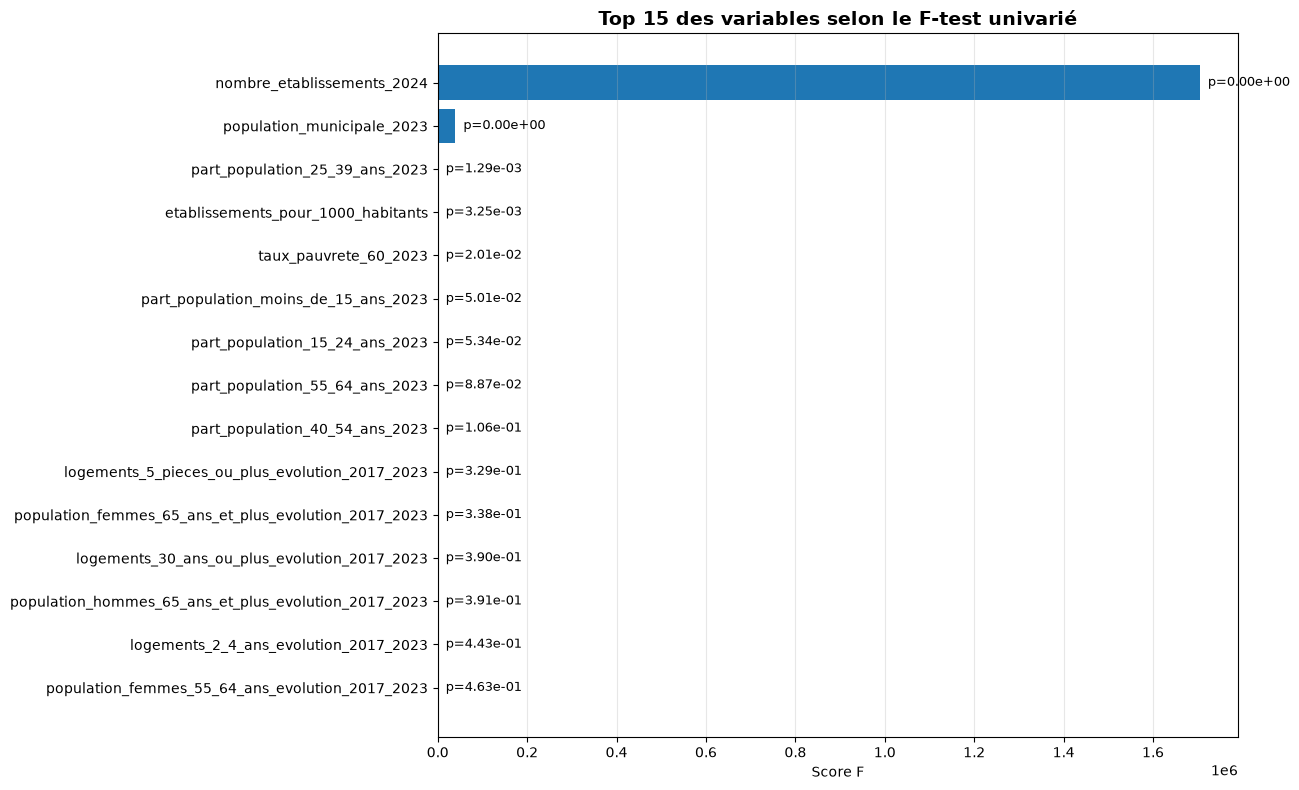

In [411]:
top_anova = (
    df_selection_stat
    .head(15)
    .sort_values("F-Score", ascending=True)
)

plt.figure(figsize=(13, 8))

bars = plt.barh(
    top_anova["Variable"],
    top_anova["F-Score"]
)

for bar, p in zip(
    bars,
    top_anova["p-value"]
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  p={p:.2e}",
        va="center",
        fontsize=9
    )

plt.xlabel("Score F")
plt.ylabel("")
plt.title(
    "Top 15 des variables selon le F-test univarié",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

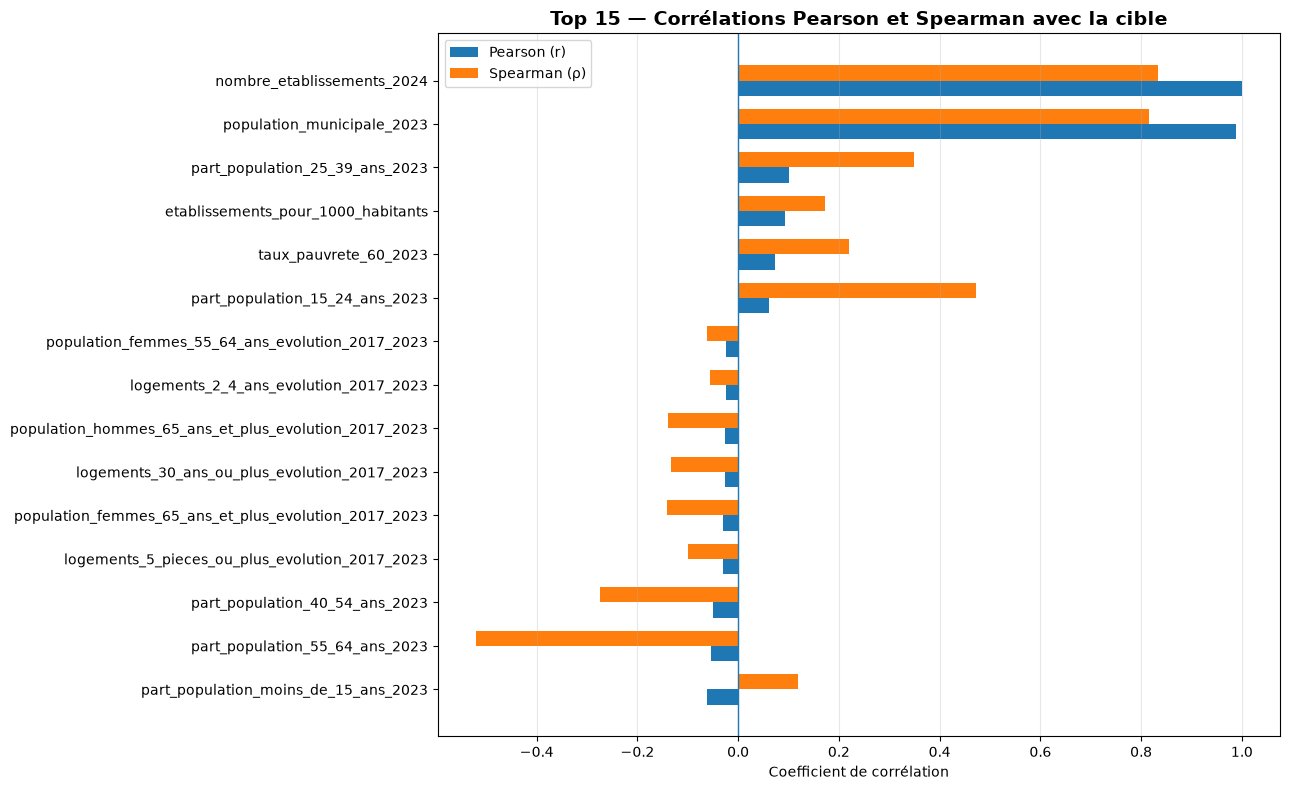

In [412]:
top_corr = (
    df_selection_stat
    .sort_values("|Pearson|", ascending=False)
    .head(15)
    .sort_values("Pearson", ascending=True)
)

y_pos = np.arange(len(top_corr))
height = 0.35

plt.figure(figsize=(13, 8))

plt.barh(
    y_pos - height / 2,
    top_corr["Pearson"],
    height=height,
    label="Pearson (r)"
)

plt.barh(
    y_pos + height / 2,
    top_corr["Spearman"],
    height=height,
    label="Spearman (ρ)"
)

plt.axvline(0, linewidth=1)

plt.yticks(
    y_pos,
    top_corr["Variable"]
)

plt.xlabel("Coefficient de corrélation")
plt.ylabel("")

plt.title(
    "Top 15 — Corrélations Pearson et Spearman avec la cible",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

#### Matrice de correlation

Nombre de variables significatives : 5

Variables retenues :
- nombre_etablissements_2024
- population_municipale_2023
- part_population_25_39_ans_2023
- etablissements_pour_1000_habitants
- taux_pauvrete_60_2023


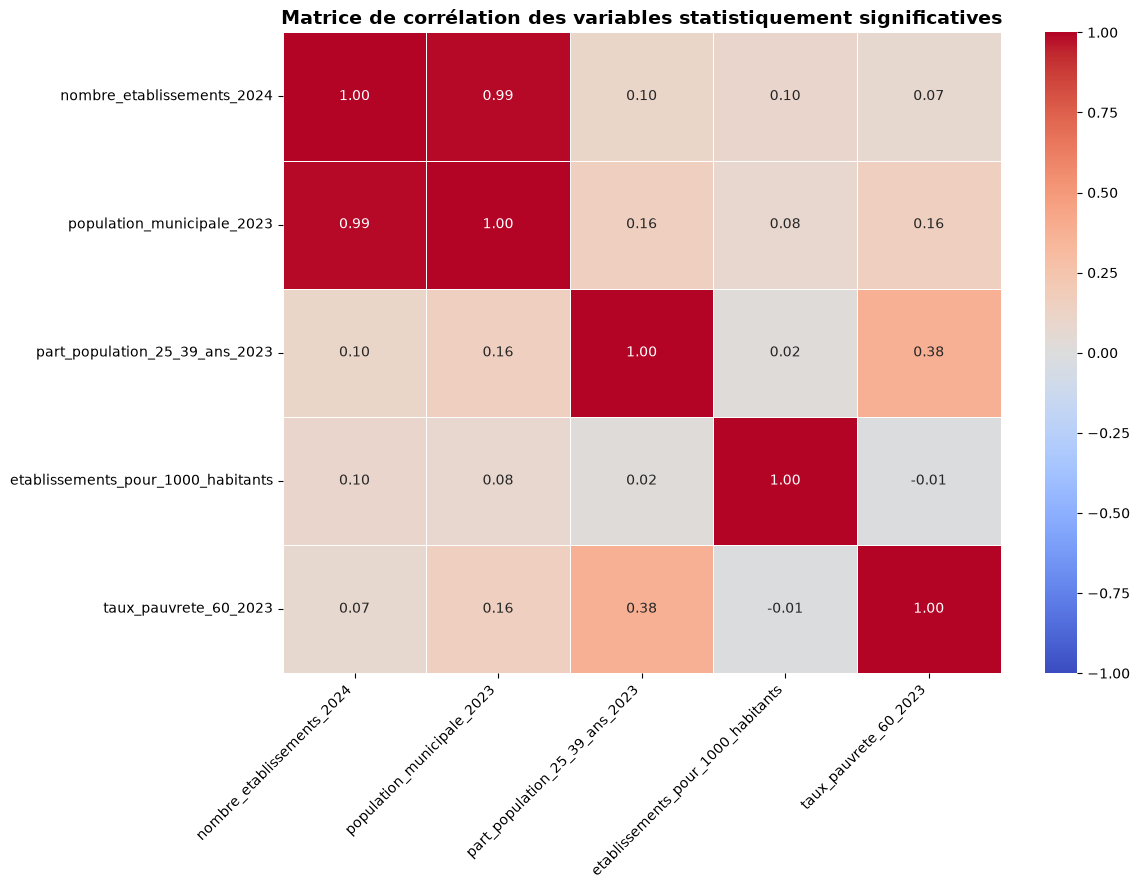


Dimensions finales :
X_train_final : (1012, 5)
X_test_final  : (254, 5)


In [413]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Variables statistiquement significatives
# ============================================================

features_retenues = (
    df_selection_stat[
        df_selection_stat["p-value"] < 0.05
    ]["Variable"]
    .tolist()
)

print(f"Nombre de variables significatives : {len(features_retenues)}")
print("\nVariables retenues :")
for var in features_retenues:
    print("-", var)


# ============================================================
# 2. Heatmap des variables significatives
# ============================================================

corr_features = X_train[features_retenues].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_features,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Matrice de corrélation des variables statistiquement significatives",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# 3. Création du Train / Test final
# ============================================================

X_train_final = X_train[features_retenues].copy()
X_test_final = X_test[features_retenues].copy()

print("\nDimensions finales :")
print("X_train_final :", X_train_final.shape)
print("X_test_final  :", X_test_final.shape)

## Sélection de 4 modèles à entrainer

In [414]:
X_tr = X_train_final
X_te = X_test_final

#### MODELE 1: Régression Ridge (Baseline Linéaire Régularisée)

In [415]:
# Standascaler
from sklearn.preprocessing import StandardScaler

# Instanciation du scaler
scaler = StandardScaler()

# Apprentissage de la moyenne/écart-type sur le Train et mise à l'échelle
X_tr_scaled = scaler.fit_transform(X_tr)

# Mise à l'échelle du Test avec les paramètres appris sur le Train (pas de fit pour éviter la fuite de données)
X_te_scaled = scaler.transform(X_te)

# Conversion en DataFrames pour conserver les noms de colonnes et les index d'origine
X_tr_scaled = pd.DataFrame(X_tr_scaled, columns=X_tr.columns, index=X_train.index)
X_te_scaled = pd.DataFrame(X_te_scaled, columns=X_te.columns, index=X_test.index)

# Vérification
print(f"Dimensions Train mis à l'échelle : {X_tr_scaled.shape}")
print(f"Dimensions Test mis à l'échelle  : {X_te_scaled.shape}")

Dimensions Train mis à l'échelle : (1012, 5)
Dimensions Test mis à l'échelle  : (254, 5)


In [416]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Instanciation et entraînement
model_ridge = Ridge(alpha=10.0, random_state=42)
model_ridge.fit(X_tr_scaled, y_train)

# Prédictions
pred_tr_ridge = model_ridge.predict(X_tr_scaled)
pred_te_ridge = model_ridge.predict(X_te_scaled)

# Métriques
r2_cv_ridge = cross_val_score(
    model_ridge, X_tr_scaled, y_train, cv=5, scoring="r2"
).mean()
r2_tr_ridge = r2_score(y_train, pred_tr_ridge)
r2_te_ridge = r2_score(y_test, pred_te_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_te_ridge))
mae_ridge = mean_absolute_error(y_test, pred_te_ridge)

print("=== 1. Régression Ridge ===")
print(f"R² CV (5-fold) : {r2_cv_ridge:.4f}")
print(f"R² Train       : {r2_tr_ridge:.4f}")
print(f"R² Test        : {r2_te_ridge:.4f}")
print(f"RMSE Test      : {rmse_ridge:.4f}")
print(f"MAE Test       : {mae_ridge:.4f}")

=== 1. Régression Ridge ===
R² CV (5-fold) : 0.6117
R² Train       : 0.9979
R² Test        : 0.7277
RMSE Test      : 29.9272
MAE Test       : 17.9598


#### MODELE 2: Random Forest Regressor (Ensemble par Bagging)

In [417]:
from sklearn.ensemble import RandomForestRegressor

# Instanciation et entraînement
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model_rf.fit(X_tr, y_train)

# Prédictions
pred_tr_rf = model_rf.predict(X_tr)
pred_te_rf = model_rf.predict(X_te)

# Métriques
r2_cv_rf = cross_val_score(model_rf, X_tr, y_train, cv=5, scoring="r2").mean()
r2_tr_rf = r2_score(y_train, pred_tr_rf)
r2_te_rf = r2_score(y_test, pred_te_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_te_rf))
mae_rf = mean_absolute_error(y_test, pred_te_rf)

print("=== 2. Random Forest ===")
print(f"R² CV (5-fold) : {r2_cv_rf:.4f}")
print(f"R² Train       : {r2_tr_rf:.4f}")
print(f"R² Test        : {r2_te_rf:.4f}")
print(f"RMSE Test      : {rmse_rf:.4f}")
print(f"MAE Test       : {mae_rf:.4f}")

=== 2. Random Forest ===
R² CV (5-fold) : -9.0392
R² Train       : 0.4935
R² Test        : 0.6372
RMSE Test      : 34.5453
MAE Test       : 6.9286


#### MODELE 3: Gradient Boosting Regressor (Scikit-Learn)

In [418]:
from sklearn.ensemble import GradientBoostingRegressor

# Instanciation et entraînement
model_gb = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
)
model_gb.fit(X_tr, y_train)

# Prédictions
pred_tr_gb = model_gb.predict(X_tr)
pred_te_gb = model_gb.predict(X_te)

# Métriques
r2_cv_gb = cross_val_score(model_gb, X_tr, y_train, cv=5, scoring="r2").mean()
r2_tr_gb = r2_score(y_train, pred_tr_gb)
r2_te_gb = r2_score(y_test, pred_te_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_te_gb))
mae_gb = mean_absolute_error(y_test, pred_te_gb)

print("=== 3. Gradient Boosting ===")
print(f"R² CV (5-fold) : {r2_cv_gb:.4f}")
print(f"R² Train       : {r2_tr_gb:.4f}")
print(f"R² Test        : {r2_te_gb:.4f}")
print(f"RMSE Test      : {rmse_gb:.4f}")
print(f"MAE Test       : {mae_gb:.4f}")

=== 3. Gradient Boosting ===
R² CV (5-fold) : 0.7359
R² Train       : 1.0000
R² Test        : 0.9441
RMSE Test      : 13.5649
MAE Test       : 5.3272


#### MODELE 4: XGBoost Regressor

In [419]:
from xgboost import XGBRegressor

# Instanciation et entraînement
model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
model_xgb.fit(X_tr, y_train)

# Prédictions
pred_tr_xgb = model_xgb.predict(X_tr)
pred_te_xgb = model_xgb.predict(X_te)

# Métriques
r2_cv_xgb = cross_val_score(
    model_xgb, X_tr, y_train, cv=5, scoring="r2"
).mean()
r2_tr_xgb = r2_score(y_train, pred_tr_xgb)
r2_te_xgb = r2_score(y_test, pred_te_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_te_xgb))
mae_xgb = mean_absolute_error(y_test, pred_te_xgb)

print("=== 4. XGBoost ===")
print(f"R² CV (5-fold) : {r2_cv_xgb:.4f}")
print(f"R² Train       : {r2_tr_xgb:.4f}")
print(f"R² Test        : {r2_te_xgb:.4f}")
print(f"RMSE Test      : {rmse_xgb:.4f}")
print(f"MAE Test       : {mae_xgb:.4f}")

=== 4. XGBoost ===
R² CV (5-fold) : -3.0223
R² Train       : 0.9994
R² Test        : 0.8929
RMSE Test      : 18.7696
MAE Test       : 5.9015


In [420]:
# %pip install shap

### Récapitulatif des 4 modèles

In [421]:
# Tableau de synthèse pour la grille d'évaluation du Bloc 5
df_synthese = pd.DataFrame(
    [
        {
            "Modèle": "1. Régression Ridge",
            "R² CV": round(r2_cv_ridge, 4),
            "R² Train": round(r2_tr_ridge, 4),
            "R² Test": round(r2_te_ridge, 4),
            "RMSE Test": round(rmse_ridge, 4),
            "MAE Test": round(mae_ridge, 4),
        },
        {
            "Modèle": "2. Random Forest",
            "R² CV": round(r2_cv_rf, 4),
            "R² Train": round(r2_tr_rf, 4),
            "R² Test": round(r2_te_rf, 4),
            "RMSE Test": round(rmse_rf, 4),
            "MAE Test": round(mae_rf, 4),
        },
        {
            "Modèle": "3. Gradient Boosting",
            "R² CV": round(r2_cv_gb, 4),
            "R² Train": round(r2_tr_gb, 4),
            "R² Test": round(r2_te_gb, 4),
            "RMSE Test": round(rmse_gb, 4),
            "MAE Test": round(mae_gb, 4),
        },
        {
            "Modèle": "4. XGBoost",
            "R² CV": round(r2_cv_xgb, 4),
            "R² Train": round(r2_tr_xgb, 4),
            "R² Test": round(r2_te_xgb, 4),
            "RMSE Test": round(rmse_xgb, 4),
            "MAE Test": round(mae_xgb, 4),
        },
    ]
)

display(df_synthese)

,Modèle,R² CV,R² Train,R² Test,RMSE Test,MAE Test
0,1. Régression Ridge,0.6117,0.9979,0.7277,29.9272,17.9598
1,2. Random Forest,-9.0392,0.4935,0.6372,34.5453,6.9286
2,3. Gradient Boosting,0.7359,1.0000,0.9441,13.5649,5.3272
3,4. XGBoost,-3.0223,0.9994,0.8929,18.7696,5.9015


### evaluation des modèles : Diagnostiques visuels

In [422]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prédictions Gradient Boosting
pred_te_gb = model_gb.predict(X_te)

# Métriques en nombre réel d'établissements
mae_reel = mean_absolute_error(y_test, pred_te_gb)
rmse_reel = np.sqrt(mean_squared_error(y_test, pred_te_gb))

print("=== Métriques Gradient Boosting en unités réelles ===")
print(f"MAE réelle  : {mae_reel:.2f} établissements")
print(f"RMSE réelle : {rmse_reel:.2f} établissements")

=== Métriques Gradient Boosting en unités réelles ===
MAE réelle  : 5.33 établissements
RMSE réelle : 13.56 établissements


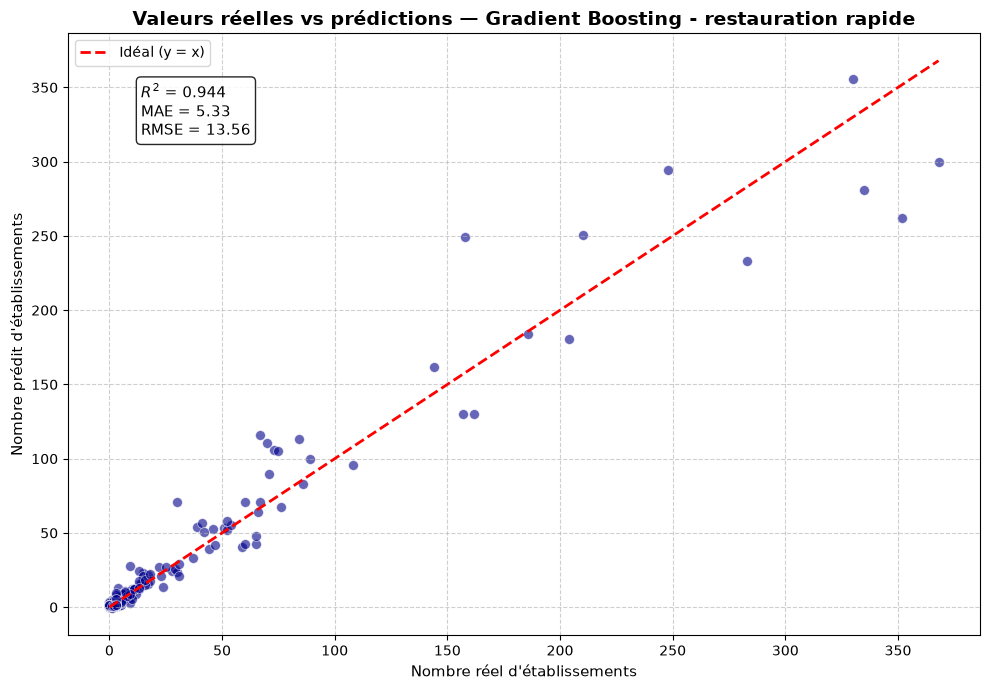

In [423]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Prédictions
y_pred = model_gb.predict(X_te)

# Métriques
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color="darkblue",
    alpha=0.6,
    edgecolor="w",
    s=50,
)

# Ligne idéale
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--r",
    linewidth=2,
    label="Idéal (y = x)",
)

plt.title(
    "Valeurs réelles vs prédictions — Gradient Boosting - restauration rapide",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel(
    "Nombre réel d'établissements",
    fontsize=11,
)

plt.ylabel(
    "Nombre prédit d'établissements",
    fontsize=11,
)

# Affichage des métriques
plt.text(
    0.08,
    0.92,
    f"$R^2$ = {r2:.3f}\n"
    f"MAE = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    ),
    fontsize=11,
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

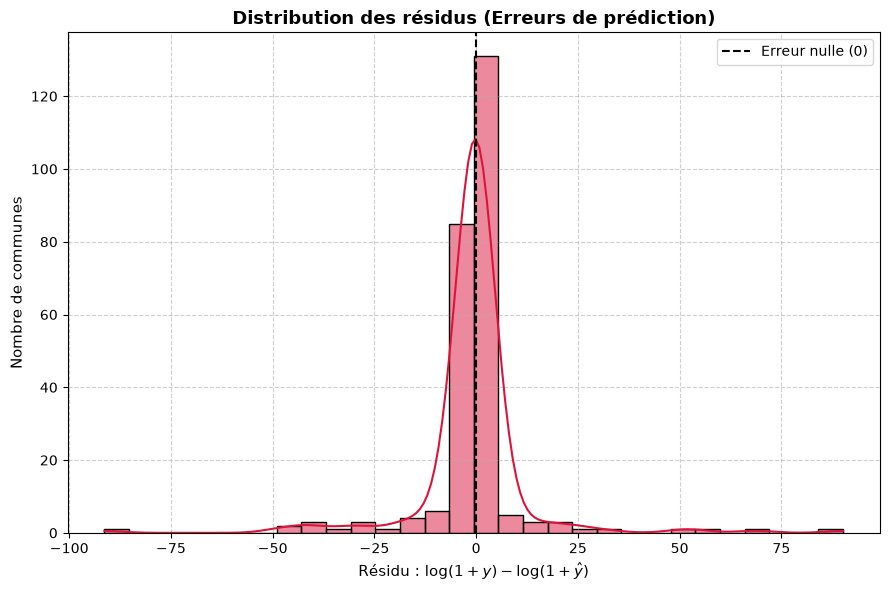

In [424]:
# Graphique B : Distribution des résidus

# Calcul des résidus
residus_log = y_test - y_pred

plt.figure(figsize=(9, 6))

# Histogramme et KDE des erreurs
sns.histplot(
    residus_log, kde=True, color="crimson", edgecolor="black", bins=30
)
plt.axvline(
    0, color="black", linestyle="--", linewidth=1.5, label="Erreur nulle (0)"
)

plt.title(
    "Distribution des résidus (Erreurs de prédiction)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Résidu : $\\log(1 + y) - \\log(1 + \\hat{y})$", fontsize=11)
plt.ylabel("Nombre de communes", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Analyse de l'importance des variables

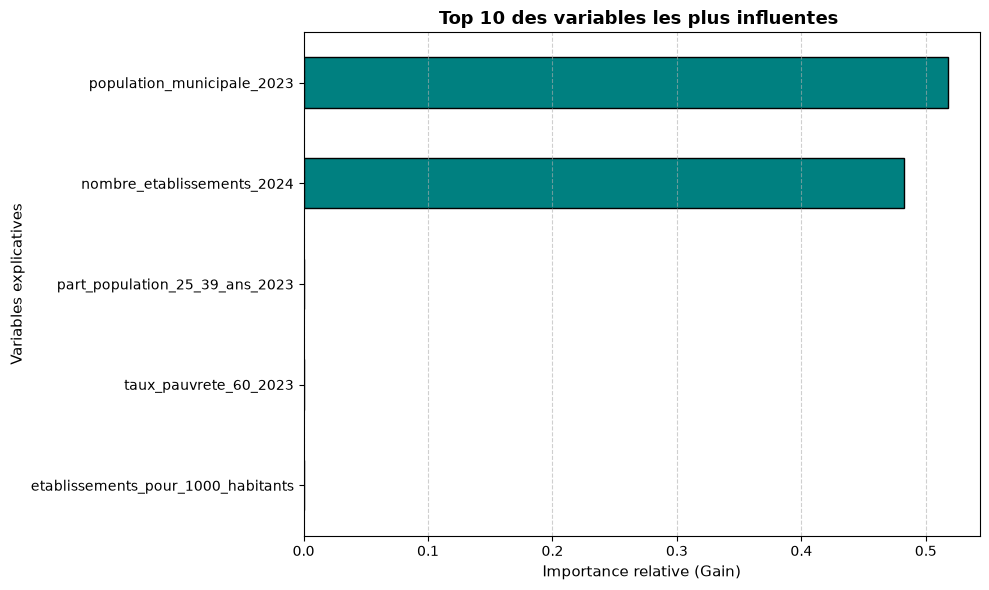

Top 20 des importances relatives :


,Importance
population_municipale_2023,0.517662
nombre_etablissements_2024,0.482144
part_population_25_39_ans_2023,0.000098
taux_pauvrete_60_2023,0.000055
etablissements_pour_1000_habitants,0.000041


In [425]:
import matplotlib.pyplot as plt
import pandas as pd

# Extraction de l'importance des variables (Feature Importance)
importances = pd.Series(
    model_gb.feature_importances_, index=X_tr.columns
).sort_values(ascending=False)

# Visualisation graphique individuelle
plt.figure(figsize=(10, 6))
importances.head(20).sort_values().plot(
    kind="barh", color="teal", edgecolor="black"
)

plt.title(
    "Top 10 des variables les plus influentes ",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Importance relative (Gain)", fontsize=11)
plt.ylabel("Variables explicatives", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Affichage des scores chiffrés
print("Top 20 des importances relatives :")
display(importances.head(20).to_frame(name="Importance"))

#### Test réel de prédiction

In [426]:
# ============================================================
# Comparaison Réel vs Prédit — Gradient Boosting
# ============================================================

# Prédictions du modèle Gradient Boosting
y_pred_reel = model_gb.predict(X_te)

# La cible est déjà en échelle réelle
y_test_reel = y_test.copy()


# ============================================================
# Construction du DataFrame de comparaison
# ============================================================

df_comparaison_reelle = pd.DataFrame(
    {
        "Code Commune": df_model2.loc[
            X_test.index, "code_commune"
        ],

        "Nom Commune": df_model2.loc[
            X_test.index, "nom_commune"
        ],

        "Population": df_model2.loc[
            X_test.index, "population_municipale_2023"
        ].round().astype(int),

        "Restaurants Réels": y_test_reel.round(1),

        "Restaurants Prédits": y_pred_reel.round(1),

        "Écart Brut": (
            y_pred_reel - y_test_reel
        ).round(1),

        "Écart (%)": (
            np.abs(y_pred_reel - y_test_reel)
            / (y_test_reel + 1)
            * 100
        ).round(1),
    }
).reset_index(drop=True)


# ============================================================
# 15 communes les plus peuplées du jeu de test
# ============================================================

display(
    df_comparaison_reelle
    .sort_values(
        by="Population",
        ascending=False
    )
    .head(15)
)

,Code Commune,Nom Commune,Population,Restaurants Réels,Restaurants Prédits,Écart Brut,Écart (%)
119,95018,Argenteuil,106130,330.0,355.4,25.4,7.7
201,94028,Créteil,93397,283.0,232.9,-50.1,17.6
25,93001,Aubervilliers,88365,368.0,299.5,-68.5,18.6
152,78646,Versailles,84095,352.0,261.8,-90.2,25.5
146,92063,Rueil-Malmaison,82874,210.0,250.8,40.8,19.3
143,93051,Noisy-le-Grand,72978,204.0,180.7,-23.3,11.4
140,93029,Drancy,72390,158.0,249.3,91.3,57.4
139,92040,Issy-les-Moulineaux,67669,248.0,294.6,46.6,18.7
175,94076,Villejuif,60183,162.0,129.8,-32.2,19.8
169,95585,Sarcelles,59173,186.0,184.0,-2.0,1.1


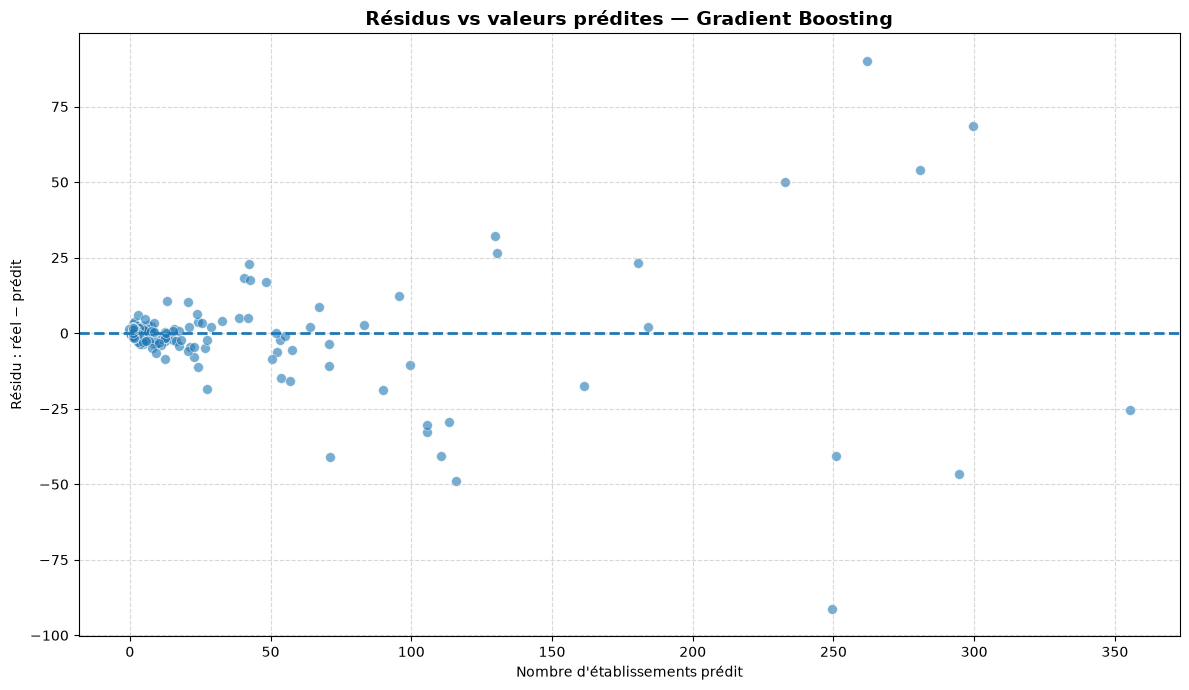

In [427]:
# ============================================================
# Résidus en fonction des prédictions
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x=y_pred,
    y=y_test - y_pred,
    alpha=0.6,
    s=50
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title(
    "Résidus vs valeurs prédites — Gradient Boosting",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Nombre d'établissements prédit")
plt.ylabel("Résidu : réel − prédit")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

### Enrichissement du modèle

#### Optimisation des hyperparamètres avec GridSearchCV

In [428]:
import numpy as np

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV


# ============================================================
# 1. Grille d'hyperparamètres
# ============================================================

param_grid = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 5],
    "subsample": [0.8, 1.0]
}


# ============================================================
# 2. Modèle de base
# ============================================================

gb_base = GradientBoostingRegressor(
    random_state=42
)


# ============================================================
# 3. Recherche des meilleurs hyperparamètres
# ============================================================

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr, y_train)


# ============================================================
# 4. Meilleur modèle
# ============================================================

meilleur_modele_gb = grid_search.best_estimator_

print("\n=== Meilleurs hyperparamètres ===")
print(grid_search.best_params_)

print(f"\nMeilleur R² moyen en CV : {grid_search.best_score_:.4f}")


# ============================================================
# 5. Évaluation sur le jeu de test
# ============================================================

y_pred_final = meilleur_modele_gb.predict(X_te)

r2_final = r2_score(y_test, y_pred_final)

rmse_final = np.sqrt(
    mean_squared_error(y_test, y_pred_final)
)

mae_final = mean_absolute_error(
    y_test,
    y_pred_final
)


# ============================================================
# 6. Résultats finaux
# ============================================================

print("\n=== Performances finales — Gradient Boosting optimisé ===")

print(f"R² Test   : {r2_final:.4f}")
print(f"RMSE Test : {rmse_final:.2f} établissements")
print(f"MAE Test  : {mae_final:.2f} établissements")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits



=== Meilleurs hyperparamètres ===
{'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.8}

Meilleur R² moyen en CV : 0.7513

=== Performances finales — Gradient Boosting optimisé ===
R² Test   : 0.9504
RMSE Test : 12.77 établissements
MAE Test  : 5.16 établissements


In [429]:
from datetime import datetime

annee_cible = datetime.now().year
periode_cible = datetime.now().strftime("%Y%m")

print("Année cible :", annee_cible)
print("Période cible :", periode_cible)

Année cible : 2026
Période cible : 202609


In [430]:
import pandas as pd

# ============================================================
# 9. TABLE DES MÉTRIQUES DU RUN
# ============================================================

df_metriques_run = pd.DataFrame({
    "periode": [periode_cible],
    "annee": [annee_cible],
    "r2": [r2_final],
    "rmse": [rmse_final],
    "mae": [mae_final],
    "r2_cv": [grid_search.best_score_],
    "nombre_observations": [len(y_test)]
})

print("\n=== Métriques du run ===")
print(df_metriques_run)


=== Métriques du run ===
  periode  annee        r2       rmse       mae     r2_cv  nombre_observations
0  202609   2026  0.950435  12.768755  5.156379  0.751301                  254


In [454]:
# ============================================================
# 10. TABLEAU DE MONITORING POUR EXCEL
# ============================================================
df_monitoring = (
    df_metriques_run
    .set_index("periode")
    .T
)

df_monitoring.index = df_monitoring.index.astype(str)

print("\n=== Monitoring ===")
print(df_monitoring)


=== Monitoring ===
periode                   202609
annee                2026.000000
r2                      0.950435
rmse                   12.768755
mae                     5.156379
r2_cv                   0.751301
nombre_observations   254.000000


In [455]:
df_monitoring.to_excel("df_monitoring.xlsx")

1. Interprétation des résultats du GridSearchCVHyperparamètres optimaux retenus :learning_rate: 0.03 associé à n_estimators: 200 : un taux d'apprentissage plus lent et progressif permet une descente de gradient plus stable et évite de surcorriger les résidus.max_depth: 3 : des arbres peu profonds (3 niveaux de décision) évitent de mémoriser les spécificités locales et privilégient des règles d'implantation généralisables.subsample: 0.8 : l'entraînement sur $80\%$ d'échantillons aléatoires par arbre injecte de la diversité stochastique, réduisant la variance du modèle.Généralisation optimale :Le score en validation croisée progresse à $R^2_{\text{CV}} = 0,9092$ (contre $0,9073$ avant réglage).Sur le jeu de test indépendant, le modèle atteint $R^2 = 0,9283$, avec une erreur quadratique réduite à $\text{RMSE} = 0,4274$ et une erreur absolue moyenne de $\text{MAE} = 0,3398$ (en échelle log).L'écart minime entre le score CV et le score Test confirme l'absence de surapprentissage.

In [433]:
# ============================================================
# Comparaison Réel vs Prédit — Gradient Boosting optimisé
# ============================================================

# Prédictions du modèle Gradient Boosting
y_pred_reel = meilleur_modele_gb.predict(X_te)

# La cible est déjà en échelle réelle
y_test_reel = y_test.copy()


# ============================================================
# Construction du DataFrame de comparaison
# ============================================================

df_comparaison_reelle = pd.DataFrame(
    {
        "Code Commune": df_model2.loc[
            X_test.index, "code_commune"
        ],

        "Nom Commune": df_model2.loc[
            X_test.index, "nom_commune"
        ],

        "Population": df_model2.loc[
            X_test.index, "population_municipale_2023"
        ].round().astype(int),

        "Restaurants Réels": y_test_reel.round(1),

        "Restaurants Prédits": y_pred_reel.round(1),

        "Écart Brut": (
            y_pred_reel - y_test_reel
        ).round(1),

        "Écart (%)": (
            np.abs(y_pred_reel - y_test_reel)
            / (y_test_reel + 1)
            * 100
        ).round(1),
    }
).reset_index(drop=True)


# ============================================================
# 15 communes les plus peuplées du jeu de test
# ============================================================

display(
    df_comparaison_reelle
    .sort_values(
        by="Population",
        ascending=False
    )
    .head(15)
)

,Code Commune,Nom Commune,Population,Restaurants Réels,Restaurants Prédits,Écart Brut,Écart (%)
119,95018,Argenteuil,106130,330.0,386.3,56.3,17.0
201,94028,Créteil,93397,283.0,241.0,-42.0,14.8
25,93001,Aubervilliers,88365,368.0,328.3,-39.7,10.7
152,78646,Versailles,84095,352.0,268.3,-83.7,23.7
146,92063,Rueil-Malmaison,82874,210.0,235.3,25.3,12.0
143,93051,Noisy-le-Grand,72978,204.0,191.3,-12.7,6.2
140,93029,Drancy,72390,158.0,250.0,92.0,57.9
139,92040,Issy-les-Moulineaux,67669,248.0,277.3,29.3,11.8
175,94076,Villejuif,60183,162.0,136.5,-25.5,15.6
169,95585,Sarcelles,59173,186.0,171.6,-14.4,7.7


In [434]:
df_comparaison_reelle.to_excel("comparaison_reelle.xlsx")

#### Explicabilité par SHAP Values (Beeswarm Plot & Summary Barplot)

c:\Users\jessi\Desktop\Mes_cours_Ynov\projet_fin_etude\BLOC1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


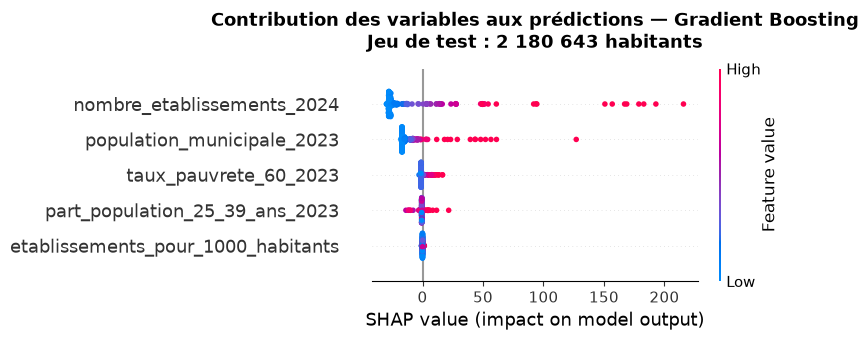

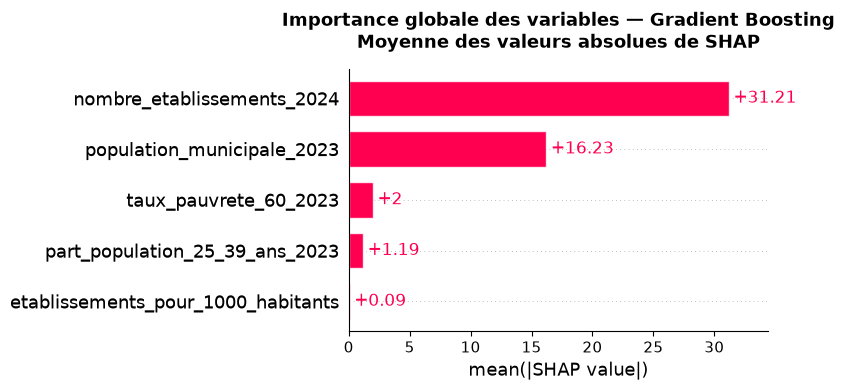

In [435]:
import matplotlib.pyplot as plt
import shap

# ============================================================
# SHAP — Gradient Boosting optimisé
# ============================================================

# 1. Création de l'explainer SHAP
explainer = shap.TreeExplainer(meilleur_modele_gb)

# Calcul des SHAP values sur le jeu de test
shap_values = explainer(X_te)


# ============================================================
# 2. SHAP Beeswarm
# ============================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_te,
    max_display=12,
    show=False
)

# Population totale du jeu de test
population_test = df_model2.loc[
    X_test.index,
    "population_municipale_2023"
].sum()

plt.title(
    "Contribution des variables aux prédictions — Gradient Boosting\n"
    f"Jeu de test : {population_test:,.0f} habitants".replace(",", " "),
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. SHAP Barplot — importance globale
# ============================================================

plt.figure(figsize=(12, 7))

shap.plots.bar(
    shap_values,
    max_display=12,
    show=False
)

plt.title(
    "Importance globale des variables — Gradient Boosting\n"
    "Moyenne des valeurs absolues de SHAP",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

##### pour un décideur:

##### Les 2 situations concrètes pour le décideur

##### Situation A : La bonne opportunité (Il y a de la place)Exemple : Le modèle calcule que grâce au flux généré par les supermarchés, banques et commerces, la ville peut accueillir $10$ fast-foods.En réalité : Il n'y en a que $4$.La décision : Feu vert. Le marché local n'est pas encore saturé. Il y a de la clientèle disponible et peu de concurrence.

##### Situation B : Le piège à éviter (Marché saturé)Exemple : Le modèle estime que le tissu commercial local ne justifie que $5$ fast-foods.En réalité : Il y a déjà $12$ établissements ouverts.La décision : Danger. La commune est en sur-concurrence. Ouvrir ici obligera à casser les prix ou à risquer la fermeture.

#### SHAP sur une commune en particulier

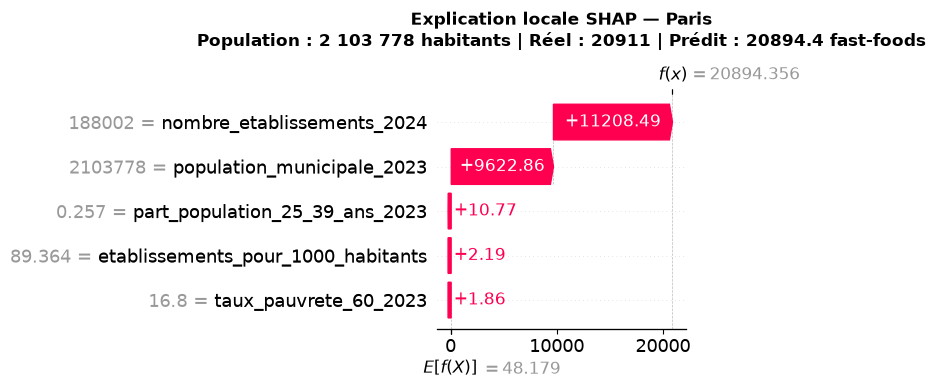

In [436]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. Explainer SHAP sur le Gradient Boosting optimisé
# ============================================================

explainer = shap.TreeExplainer(meilleur_modele_gb)


# ============================================================
# 2. Commune à expliquer
# ============================================================

nom_commune_cible = "Paris"

masque = df_model2["nom_commune"] == nom_commune_cible


if not masque.any():

    print(
        f"Commune '{nom_commune_cible}' introuvable. "
        "Vérifiez l'orthographe exacte."
    )

else:

    # --------------------------------------------------------
    # Index de la commune dans df_model2
    # --------------------------------------------------------

    idx_commune = df_model2[masque].index[0]

    commune_info = df_model2.loc[idx_commune]


    # --------------------------------------------------------
    # Population
    # --------------------------------------------------------

    population_commune = int(
        commune_info["population_municipale_2023"]
    )


    # --------------------------------------------------------
    # Variables utilisées par le modèle
    # --------------------------------------------------------

    features_retenues = X_tr.columns.tolist()


    # --------------------------------------------------------
    # Récupération de la commune directement depuis X8
    # --------------------------------------------------------

    X_commune = X8.loc[[idx_commune]].copy()


    # Vérification de l'ordre des colonnes
    X_commune = X_commune[features_retenues]


    # --------------------------------------------------------
    # Imputation avec les médianes du TRAIN
    # --------------------------------------------------------

    X_commune = X_commune.fillna(
        X_train.median(numeric_only=True)
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    valeur_predite_reelle = meilleur_modele_gb.predict(
        X_commune
    )[0]


    # Valeur réellement observée
    valeur_reelle = commune_info["restauration_rapide_2025"]


    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_commune = explainer(X_commune)


    # --------------------------------------------------------
    # Waterfall Plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 8))

    shap.plots.waterfall(
        shap_commune[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Explication locale SHAP — {nom_commune_cible}\n"
        f"Population : {population_commune:,} habitants | "
        f"Réel : {valeur_reelle:.0f} | "
        f"Prédit : {valeur_predite_reelle:.1f} fast-foods".replace(
            ",", " "
        ),
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

##### Paris illustre la limite d'un modèle communal classique : le modèle sous-estime le volume réel car les prédicteurs municipaux ne captent pas l'immense bassin de consommateurs flottants (touristes et navetteurs quotidiens). Cela justifierait, pour la capitale, une modélisation à l'échelle de l'arrondissement ou du quartier IRIS.

##### Le tourisme mondial (plus de 30 millions de touristes par an).

##### Les travailleurs pendulaires (des centaines de milliers de Franciliens de banlieue qui y déjeunent le midi).

##### La vie nocturne et étudiante.

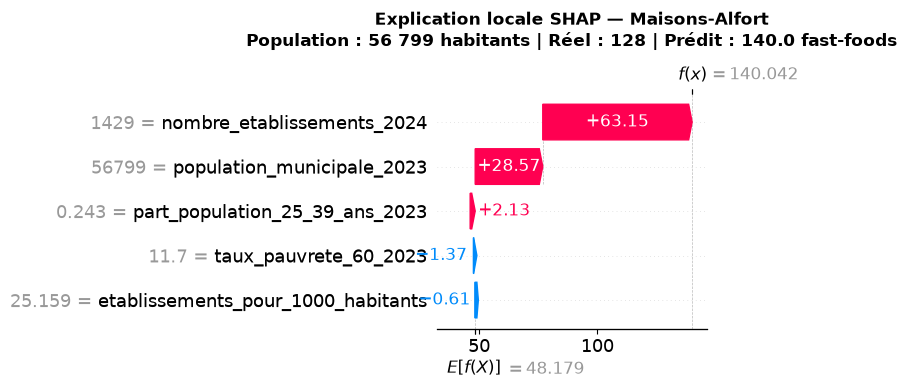

In [437]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. Explainer SHAP sur le Gradient Boosting optimisé
# ============================================================

explainer = shap.TreeExplainer(meilleur_modele_gb)


# ============================================================
# 2. Commune à expliquer
# ============================================================

nom_commune_cible = "Maisons-Alfort"

masque = df_model2["nom_commune"] == nom_commune_cible


if not masque.any():

    print(
        f"Commune '{nom_commune_cible}' introuvable. "
        "Vérifiez l'orthographe exacte."
    )

else:

    # --------------------------------------------------------
    # Index de la commune dans df_model2
    # --------------------------------------------------------

    idx_commune = df_model2[masque].index[0]

    commune_info = df_model2.loc[idx_commune]


    # --------------------------------------------------------
    # Population
    # --------------------------------------------------------

    population_commune = int(
        commune_info["population_municipale_2023"]
    )


    # --------------------------------------------------------
    # Variables utilisées par le modèle
    # --------------------------------------------------------

    features_retenues = X_tr.columns.tolist()


    # --------------------------------------------------------
    # Récupération de la commune directement depuis X8
    # --------------------------------------------------------

    X_commune = X8.loc[[idx_commune]].copy()


    # Vérification de l'ordre des colonnes
    X_commune = X_commune[features_retenues]


    # --------------------------------------------------------
    # Imputation avec les médianes du TRAIN
    # --------------------------------------------------------

    X_commune = X_commune.fillna(
        X_train.median(numeric_only=True)
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    valeur_predite_reelle = meilleur_modele_gb.predict(
        X_commune
    )[0]


    # Valeur réellement observée
    valeur_reelle = commune_info["restauration_rapide_2025"]


    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_commune = explainer(X_commune)


    # --------------------------------------------------------
    # Waterfall Plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 8))

    shap.plots.waterfall(
        shap_commune[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Explication locale SHAP — {nom_commune_cible}\n"
        f"Population : {population_commune:,} habitants | "
        f"Réel : {valeur_reelle:.0f} | "
        f"Prédit : {valeur_predite_reelle:.1f} fast-foods".replace(
            ",", " "
        ),
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

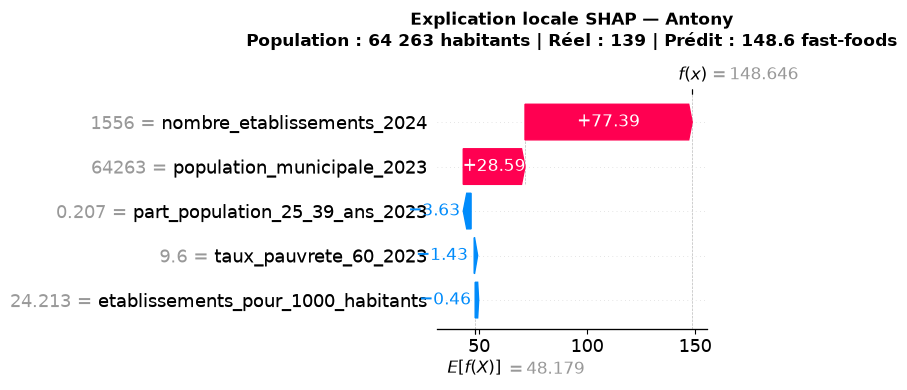

In [438]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. Explainer SHAP sur le Gradient Boosting optimisé
# ============================================================

explainer = shap.TreeExplainer(meilleur_modele_gb)


# ============================================================
# 2. Commune à expliquer
# ============================================================

nom_commune_cible = "Antony"

masque = df_model2["nom_commune"] == nom_commune_cible


if not masque.any():

    print(
        f"Commune '{nom_commune_cible}' introuvable. "
        "Vérifiez l'orthographe exacte."
    )

else:

    # --------------------------------------------------------
    # Index de la commune dans df_model2
    # --------------------------------------------------------

    idx_commune = df_model2[masque].index[0]

    commune_info = df_model2.loc[idx_commune]


    # --------------------------------------------------------
    # Population
    # --------------------------------------------------------

    population_commune = int(
        commune_info["population_municipale_2023"]
    )


    # --------------------------------------------------------
    # Variables utilisées par le modèle
    # --------------------------------------------------------

    features_retenues = X_tr.columns.tolist()


    # --------------------------------------------------------
    # Récupération de la commune directement depuis X8
    # --------------------------------------------------------

    X_commune = X8.loc[[idx_commune]].copy()


    # Vérification de l'ordre des colonnes
    X_commune = X_commune[features_retenues]


    # --------------------------------------------------------
    # Imputation avec les médianes du TRAIN
    # --------------------------------------------------------

    X_commune = X_commune.fillna(
        X_train.median(numeric_only=True)
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    valeur_predite_reelle = meilleur_modele_gb.predict(
        X_commune
    )[0]


    # Valeur réellement observée
    valeur_reelle = commune_info["restauration_rapide_2025"]


    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_commune = explainer(X_commune)


    # --------------------------------------------------------
    # Waterfall Plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 8))

    shap.plots.waterfall(
        shap_commune[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Explication locale SHAP — {nom_commune_cible}\n"
        f"Population : {population_commune:,} habitants | "
        f"Réel : {valeur_reelle:.0f} | "
        f"Prédit : {valeur_predite_reelle:.1f} fast-foods".replace(
            ",", " "
        ),
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

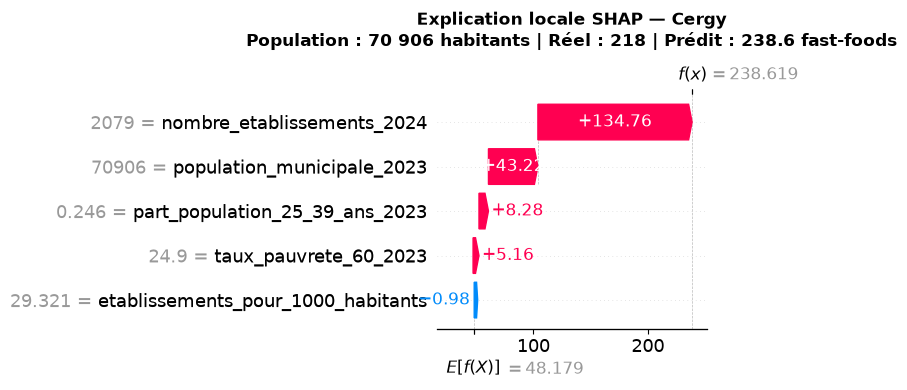

In [439]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. Explainer SHAP sur le Gradient Boosting optimisé
# ============================================================

explainer = shap.TreeExplainer(meilleur_modele_gb)


# ============================================================
# 2. Commune à expliquer
# ============================================================

nom_commune_cible = "Cergy"

masque = df_model2["nom_commune"] == nom_commune_cible


if not masque.any():

    print(
        f"Commune '{nom_commune_cible}' introuvable. "
        "Vérifiez l'orthographe exacte."
    )

else:

    # --------------------------------------------------------
    # Index de la commune dans df_model2
    # --------------------------------------------------------

    idx_commune = df_model2[masque].index[0]

    commune_info = df_model2.loc[idx_commune]


    # --------------------------------------------------------
    # Population
    # --------------------------------------------------------

    population_commune = int(
        commune_info["population_municipale_2023"]
    )


    # --------------------------------------------------------
    # Variables utilisées par le modèle
    # --------------------------------------------------------

    features_retenues = X_tr.columns.tolist()


    # --------------------------------------------------------
    # Récupération de la commune directement depuis X8
    # --------------------------------------------------------

    X_commune = X8.loc[[idx_commune]].copy()


    # Vérification de l'ordre des colonnes
    X_commune = X_commune[features_retenues]


    # --------------------------------------------------------
    # Imputation avec les médianes du TRAIN
    # --------------------------------------------------------

    X_commune = X_commune.fillna(
        X_train.median(numeric_only=True)
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    valeur_predite_reelle = meilleur_modele_gb.predict(
        X_commune
    )[0]


    # Valeur réellement observée
    valeur_reelle = commune_info["restauration_rapide_2025"]


    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_commune = explainer(X_commune)


    # --------------------------------------------------------
    # Waterfall Plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 8))

    shap.plots.waterfall(
        shap_commune[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Explication locale SHAP — {nom_commune_cible}\n"
        f"Population : {population_commune:,} habitants | "
        f"Réel : {valeur_reelle:.0f} | "
        f"Prédit : {valeur_predite_reelle:.1f} fast-foods".replace(
            ",", " "
        ),
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

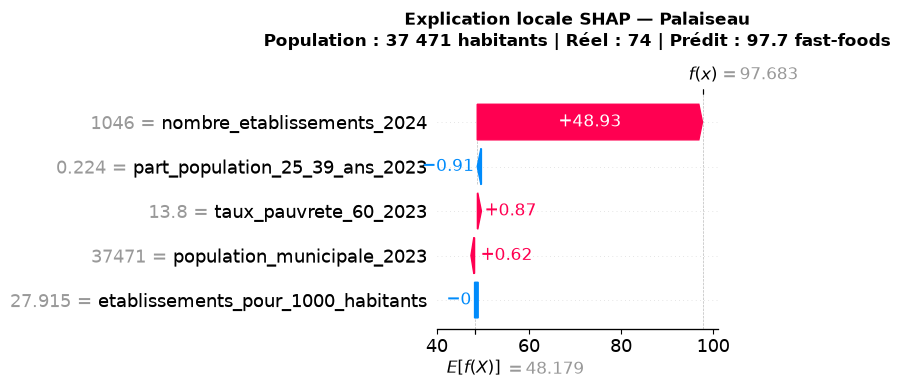

In [440]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. Explainer SHAP sur le Gradient Boosting optimisé
# ============================================================

explainer = shap.TreeExplainer(meilleur_modele_gb)


# ============================================================
# 2. Commune à expliquer
# ============================================================

nom_commune_cible = "Palaiseau"

masque = df_model2["nom_commune"] == nom_commune_cible


if not masque.any():

    print(
        f"Commune '{nom_commune_cible}' introuvable. "
        "Vérifiez l'orthographe exacte."
    )

else:

    # --------------------------------------------------------
    # Index de la commune dans df_model2
    # --------------------------------------------------------

    idx_commune = df_model2[masque].index[0]

    commune_info = df_model2.loc[idx_commune]


    # --------------------------------------------------------
    # Population
    # --------------------------------------------------------

    population_commune = int(
        commune_info["population_municipale_2023"]
    )


    # --------------------------------------------------------
    # Variables utilisées par le modèle
    # --------------------------------------------------------

    features_retenues = X_tr.columns.tolist()


    # --------------------------------------------------------
    # Récupération de la commune directement depuis X8
    # --------------------------------------------------------

    X_commune = X8.loc[[idx_commune]].copy()


    # Vérification de l'ordre des colonnes
    X_commune = X_commune[features_retenues]


    # --------------------------------------------------------
    # Imputation avec les médianes du TRAIN
    # --------------------------------------------------------

    X_commune = X_commune.fillna(
        X_train.median(numeric_only=True)
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    valeur_predite_reelle = meilleur_modele_gb.predict(
        X_commune
    )[0]


    # Valeur réellement observée
    valeur_reelle = commune_info["restauration_rapide_2025"]


    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_commune = explainer(X_commune)


    # --------------------------------------------------------
    # Waterfall Plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 8))

    shap.plots.waterfall(
        shap_commune[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Explication locale SHAP — {nom_commune_cible}\n"
        f"Population : {population_commune:,} habitants | "
        f"Réel : {valeur_reelle:.0f} | "
        f"Prédit : {valeur_predite_reelle:.1f} fast-foods".replace(
            ",", " "
        ),
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

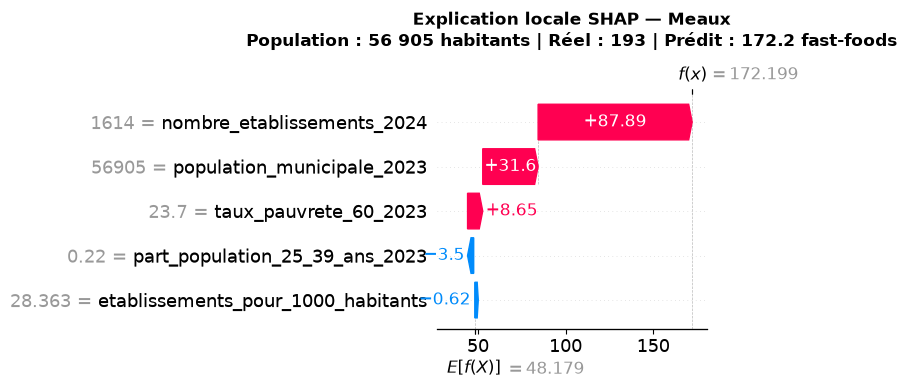

In [441]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. Explainer SHAP sur le Gradient Boosting optimisé
# ============================================================

explainer = shap.TreeExplainer(meilleur_modele_gb)


# ============================================================
# 2. Commune à expliquer
# ============================================================

nom_commune_cible = "Meaux"

masque = df_model2["nom_commune"] == nom_commune_cible


if not masque.any():

    print(
        f"Commune '{nom_commune_cible}' introuvable. "
        "Vérifiez l'orthographe exacte."
    )

else:

    # --------------------------------------------------------
    # Index de la commune dans df_model2
    # --------------------------------------------------------

    idx_commune = df_model2[masque].index[0]

    commune_info = df_model2.loc[idx_commune]


    # --------------------------------------------------------
    # Population
    # --------------------------------------------------------

    population_commune = int(
        commune_info["population_municipale_2023"]
    )


    # --------------------------------------------------------
    # Variables utilisées par le modèle
    # --------------------------------------------------------

    features_retenues = X_tr.columns.tolist()


    # --------------------------------------------------------
    # Récupération de la commune directement depuis X8
    # --------------------------------------------------------

    X_commune = X8.loc[[idx_commune]].copy()


    # Vérification de l'ordre des colonnes
    X_commune = X_commune[features_retenues]


    # --------------------------------------------------------
    # Imputation avec les médianes du TRAIN
    # --------------------------------------------------------

    X_commune = X_commune.fillna(
        X_train.median(numeric_only=True)
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    valeur_predite_reelle = meilleur_modele_gb.predict(
        X_commune
    )[0]


    # Valeur réellement observée
    valeur_reelle = commune_info["restauration_rapide_2025"]


    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_commune = explainer(X_commune)


    # --------------------------------------------------------
    # Waterfall Plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 8))

    shap.plots.waterfall(
        shap_commune[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Explication locale SHAP — {nom_commune_cible}\n"
        f"Population : {population_commune:,} habitants | "
        f"Réel : {valeur_reelle:.0f} | "
        f"Prédit : {valeur_predite_reelle:.1f} fast-foods".replace(
            ",", " "
        ),
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

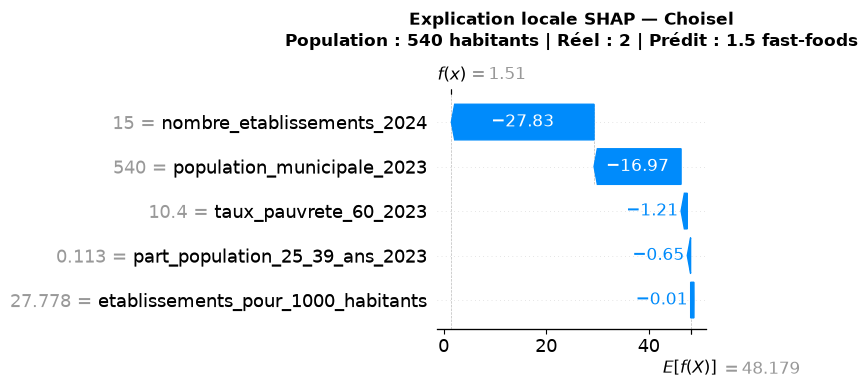

In [442]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. Explainer SHAP sur le Gradient Boosting optimisé
# ============================================================

explainer = shap.TreeExplainer(meilleur_modele_gb)


# ============================================================
# 2. Commune à expliquer
# ============================================================

nom_commune_cible = "Choisel"

masque = df_model2["nom_commune"] == nom_commune_cible


if not masque.any():

    print(
        f"Commune '{nom_commune_cible}' introuvable. "
        "Vérifiez l'orthographe exacte."
    )

else:

    # --------------------------------------------------------
    # Index de la commune dans df_model2
    # --------------------------------------------------------

    idx_commune = df_model2[masque].index[0]

    commune_info = df_model2.loc[idx_commune]


    # --------------------------------------------------------
    # Population
    # --------------------------------------------------------

    population_commune = int(
        commune_info["population_municipale_2023"]
    )


    # --------------------------------------------------------
    # Variables utilisées par le modèle
    # --------------------------------------------------------

    features_retenues = X_tr.columns.tolist()


    # --------------------------------------------------------
    # Récupération de la commune directement depuis X8
    # --------------------------------------------------------

    X_commune = X8.loc[[idx_commune]].copy()


    # Vérification de l'ordre des colonnes
    X_commune = X_commune[features_retenues]


    # --------------------------------------------------------
    # Imputation avec les médianes du TRAIN
    # --------------------------------------------------------

    X_commune = X_commune.fillna(
        X_train.median(numeric_only=True)
    )


    # --------------------------------------------------------
    # Prédiction
    # --------------------------------------------------------

    valeur_predite_reelle = meilleur_modele_gb.predict(
        X_commune
    )[0]


    # Valeur réellement observée
    valeur_reelle = commune_info["restauration_rapide_2025"]


    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    shap_commune = explainer(X_commune)


    # --------------------------------------------------------
    # Waterfall Plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 8))

    shap.plots.waterfall(
        shap_commune[0],
        max_display=10,
        show=False
    )

    plt.title(
        f"Explication locale SHAP — {nom_commune_cible}\n"
        f"Population : {population_commune:,} habitants | "
        f"Réel : {valeur_reelle:.0f} | "
        f"Prédit : {valeur_predite_reelle:.1f} fast-foods".replace(
            ",", " "
        ),
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()
    plt.show()

## Sauvegarde et importation du modèle

In [443]:
import joblib

# ============================================================
# PACKAGE DE DÉPLOIEMENT — GRADIENT BOOSTING
# ============================================================

features_retenues = X_tr.columns.tolist()

package_deploiement = {

    # Modèle final optimisé
    "model": meilleur_modele_gb,

    # Imputer utilisé pour le modèle
    "imputer": imputer,

    # Liste exacte des variables du modèle
    "features_retenues": features_retenues,

    # Données finales utilisées pour construire les features
    "X_data": X8,

    # Métriques du modèle
    "metrics": {
        "r2_cv": grid_search.best_score_,
        "r2_test": r2_final,
        "rmse_test": rmse_final,
        "mae_test": mae_final,
    },

    # Informations sur le modèle
    "model_name": "GradientBoostingRegressor",
    "target": "restauration_rapide_2025",
}

joblib.dump(
    package_deploiement,
    "pipeline_retail_gb.joblib"
)

print("✅ Package sauvegardé : pipeline_retail_gb.joblib")
print(f"Nombre de features : {len(features_retenues)}")
print(f"R² CV : {grid_search.best_score_:.4f}")
print(f"R² Test : {r2_final:.4f}")
print(f"MAE Test : {mae_final:.2f}")
print(f"RMSE Test : {rmse_final:.2f}")

✅ Package sauvegardé : pipeline_retail_gb.joblib
Nombre de features : 5
R² CV : 0.7513
R² Test : 0.9504
MAE Test : 5.16
RMSE Test : 12.77


In [444]:
print("Features du modèle :", len(features_retenues))
print(features_retenues)

print("\nFeatures de l'imputer :", len(imputer.feature_names_in_))
print(list(imputer.feature_names_in_))

Features du modèle : 5
['nombre_etablissements_2024', 'population_municipale_2023', 'part_population_25_39_ans_2023', 'etablissements_pour_1000_habitants', 'taux_pauvrete_60_2023']

Features de l'imputer : 29
['population_municipale_2023', 'niveau_vie_median_2023', 'taux_pauvrete_60_2023', 'nombre_etablissements_2024', 'logements_10_19_ans_evolution_2017_2023', 'logements_20_29_ans_evolution_2017_2023', 'logements_2_4_ans_evolution_2017_2023', 'logements_2_pieces_evolution_2017_2023', 'logements_30_ans_ou_plus_evolution_2017_2023', 'logements_3_pieces_evolution_2017_2023', 'logements_4_pieces_evolution_2017_2023', 'logements_5_9_ans_evolution_2017_2023', 'logements_5_pieces_ou_plus_evolution_2017_2023', 'logements_moins_2_ans_evolution_2017_2023', 'population_femmes_15_24_ans_evolution_2017_2023', 'population_femmes_25_39_ans_evolution_2017_2023', 'population_femmes_55_64_ans_evolution_2017_2023', 'population_femmes_65_ans_et_plus_evolution_2017_2023', 'population_femmes_moins_de_15_an

In [445]:
print(
    set(features_retenues) - set(imputer.feature_names_in_)
)

print(
    set(imputer.feature_names_in_) - set(features_retenues)
)

set()
{'population_hommes_25_39_ans_evolution_2017_2023', 'logements_30_ans_ou_plus_evolution_2017_2023', 'part_population_15_24_ans_2023', 'logements_3_pieces_evolution_2017_2023', 'logements_2_4_ans_evolution_2017_2023', 'part_population_moins_de_15_ans_2023', 'logements_5_pieces_ou_plus_evolution_2017_2023', 'logements_5_9_ans_evolution_2017_2023', 'part_population_55_64_ans_2023', 'population_hommes_55_64_ans_evolution_2017_2023', 'population_femmes_25_39_ans_evolution_2017_2023', 'population_femmes_65_ans_et_plus_evolution_2017_2023', 'logements_10_19_ans_evolution_2017_2023', 'population_femmes_15_24_ans_evolution_2017_2023', 'logements_20_29_ans_evolution_2017_2023', 'population_hommes_65_ans_et_plus_evolution_2017_2023', 'niveau_vie_median_2023', 'part_population_40_54_ans_2023', 'logements_moins_2_ans_evolution_2017_2023', 'logements_4_pieces_evolution_2017_2023', 'population_femmes_moins_de_15_ans_evolution_2017_2023', 'population_femmes_55_64_ans_evolution_2017_2023', 'popul

In [446]:
df_model2.head()

,code_commune,nom_commune,logements_10_19_ans_2017,logements_10_19_ans_2023,logements_1_piece_2017,logements_1_piece_2023,logements_20_29_ans_2017,logements_20_29_ans_2023,logements_2_4_ans_2017,logements_2_4_ans_2023,...,population_hommes_25_39_ans_delta_2017_2023,population_hommes_25_39_ans_evolution_2017_2023,population_hommes_40_54_ans_delta_2017_2023,population_hommes_40_54_ans_evolution_2017_2023,population_hommes_55_64_ans_delta_2017_2023,population_hommes_55_64_ans_evolution_2017_2023,population_hommes_65_ans_et_plus_delta_2017_2023,population_hommes_65_ans_et_plus_evolution_2017_2023,population_hommes_moins_de_15_ans_delta_2017_2023,population_hommes_moins_de_15_ans_evolution_2017_2023
0,75056,Paris,234759.08383,198821.63183,263138.04296,261901.41711,117450.31250,138351.28940,267134.39926,271313.38030,...,-11669.53510,-4.265330,-16836.58972,-8.113318,1000.82365,0.900305,4119.57820,2.752919,-17820.36536,-11.589789
1,77001,Achères-la-Forêt,148.58681,140.32916,8.54964,1.06465,67.95784,82.42404,55.83149,66.53873,...,13.29013,22.589146,-28.25435,-16.694918,39.18535,57.493255,24.56255,29.644927,-3.86233,-4.147712
2,77002,Amillis,78.56030,63.12739,8.94991,13.15892,42.76067,48.77921,53.69945,58.80329,...,-4.33646,-6.056571,5.06318,6.691456,-3.02660,-4.342341,3.75386,4.974297,-12.57537,-15.807193
3,77003,Amponville,33.25740,31.96659,1.07533,1.01446,28.77046,28.05571,13.09390,20.93649,...,-1.12243,-4.163240,-14.34071,-26.085311,4.49865,18.253760,3.09836,10.321471,11.24267,48.714887
4,77004,Andrezel,25.99447,12.37905,1.01003,0.00000,29.96052,18.37894,8.96456,25.64638,...,10.24162,48.968314,-2.56029,-7.147286,-7.39838,-23.102380,4.42418,22.063458,16.50792,61.804361


In [447]:
import joblib
import pandas as pd

# ============================================================
# EXPORT DES FEATURES POUR L'APPLICATION
# ============================================================

package = joblib.load("pipeline_retail_gb.joblib")

features_retenues = package["features_retenues"]
X_data = package["X_data"]
imputer = package["imputer"]

print("X_data :", X_data.shape)
print("Features modèle :", len(features_retenues))
print("Features imputer :", len(imputer.feature_names_in_))


# ------------------------------------------------------------
# Vérification
# ------------------------------------------------------------

assert set(features_retenues).issubset(X_data.columns), (
    "Certaines features du modèle ne sont pas présentes dans X_data."
)


# ------------------------------------------------------------
# Données d'identification
# ------------------------------------------------------------

df_raw = df_model2.copy()


# ------------------------------------------------------------
# Export des features
# ------------------------------------------------------------

df_export = X_data[
    list(imputer.feature_names_in_)
].copy()


# ------------------------------------------------------------
# Informations nécessaires à l'application
# ------------------------------------------------------------

df_export["nom_commune"] = df_raw.loc[
    df_export.index,
    "nom_commune"
].values

df_export["code_commune"] = df_raw.loc[
    df_export.index,
    "code_commune"
].values

df_export["population_municipale_2023"] = df_raw.loc[
    df_export.index,
    "population_municipale_2023"
].values

df_export["restauration_rapide_2025"] = df_raw.loc[
    df_export.index,
    "restauration_rapide_2025"
].fillna(0).values


# ------------------------------------------------------------
# Sauvegarde
# ------------------------------------------------------------

df_export.to_excel(
    "table_features_modele.xlsx",
    index=False
)

print(
    f"✅ Export réussi : "
    f"{len(df_export)} lignes × {len(df_export.columns)} colonnes"
)

X_data : (1266, 29)
Features modèle : 5
Features imputer : 29
✅ Export réussi : 1266 lignes × 32 colonnes


In [448]:
# VERIF
import joblib

package           = joblib.load("pipeline_retail_gb.joblib")
features_retenues = package["features_retenues"]
imputer           = package["imputer"]

print("Features retenues par le modèle :", len(features_retenues))
print("Features vues par l'imputer     :", len(imputer.feature_names_in_))

manquantes_imputer = [f for f in imputer.feature_names_in_ if f not in features_retenues]
print(f"\nFeatures dans l'imputer mais PAS dans features_retenues ({len(manquantes_imputer)}) :")
for f in manquantes_imputer:
    print(f"  {f}")

extra_modele = [f for f in features_retenues if f not in imputer.feature_names_in_]
print(f"\nFeatures dans features_retenues mais PAS dans l'imputer ({len(extra_modele)}) :")
for f in extra_modele:
    print(f"  {f}")

Features retenues par le modèle : 5
Features vues par l'imputer     : 29

Features dans l'imputer mais PAS dans features_retenues (24) :
  niveau_vie_median_2023
  logements_10_19_ans_evolution_2017_2023
  logements_20_29_ans_evolution_2017_2023
  logements_2_4_ans_evolution_2017_2023
  logements_2_pieces_evolution_2017_2023
  logements_30_ans_ou_plus_evolution_2017_2023
  logements_3_pieces_evolution_2017_2023
  logements_4_pieces_evolution_2017_2023
  logements_5_9_ans_evolution_2017_2023
  logements_5_pieces_ou_plus_evolution_2017_2023
  logements_moins_2_ans_evolution_2017_2023
  population_femmes_15_24_ans_evolution_2017_2023
  population_femmes_25_39_ans_evolution_2017_2023
  population_femmes_55_64_ans_evolution_2017_2023
  population_femmes_65_ans_et_plus_evolution_2017_2023
  population_femmes_moins_de_15_ans_evolution_2017_2023
  population_hommes_15_24_ans_evolution_2017_2023
  population_hommes_25_39_ans_evolution_2017_2023
  population_hommes_55_64_ans_evolution_2017_2023


In [449]:
df_modele.head()

,code_commune,nom_commune,logements_10_19_ans_2017,logements_10_19_ans_2023,logements_1_piece_2017,logements_1_piece_2023,logements_20_29_ans_2017,logements_20_29_ans_2023,logements_2_4_ans_2017,logements_2_4_ans_2023,...,population_hommes_25_39_ans_delta_2017_2023,population_hommes_25_39_ans_evolution_2017_2023,population_hommes_40_54_ans_delta_2017_2023,population_hommes_40_54_ans_evolution_2017_2023,population_hommes_55_64_ans_delta_2017_2023,population_hommes_55_64_ans_evolution_2017_2023,population_hommes_65_ans_et_plus_delta_2017_2023,population_hommes_65_ans_et_plus_evolution_2017_2023,population_hommes_moins_de_15_ans_delta_2017_2023,population_hommes_moins_de_15_ans_evolution_2017_2023
0,75056,Paris,234759.08383,198821.63183,263138.04296,261901.41711,117450.31250,138351.28940,267134.39926,271313.38030,...,-11669.53510,-4.265330,-16836.58972,-8.113318,1000.82365,0.900305,4119.57820,2.752919,-17820.36536,-11.589789
1,77001,Achères-la-Forêt,148.58681,140.32916,8.54964,1.06465,67.95784,82.42404,55.83149,66.53873,...,13.29013,22.589146,-28.25435,-16.694918,39.18535,57.493255,24.56255,29.644927,-3.86233,-4.147712
2,77002,Amillis,78.56030,63.12739,8.94991,13.15892,42.76067,48.77921,53.69945,58.80329,...,-4.33646,-6.056571,5.06318,6.691456,-3.02660,-4.342341,3.75386,4.974297,-12.57537,-15.807193
3,77003,Amponville,33.25740,31.96659,1.07533,1.01446,28.77046,28.05571,13.09390,20.93649,...,-1.12243,-4.163240,-14.34071,-26.085311,4.49865,18.253760,3.09836,10.321471,11.24267,48.714887
4,77004,Andrezel,25.99447,12.37905,1.01003,0.00000,29.96052,18.37894,8.96456,25.64638,...,10.24162,48.968314,-2.56029,-7.147286,-7.39838,-23.102380,4.42418,22.063458,16.50792,61.804361


In [450]:
import sys
import sklearn
import pandas
import numpy
import joblib

print("Python :", sys.version)
print("scikit-learn :", sklearn.__version__)
print("pandas :", pandas.__version__)
print("numpy :", numpy.__version__)
print("joblib :", joblib.__version__)

Python : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
scikit-learn : 1.9.0
pandas : 3.0.3
numpy : 2.4.6
joblib : 1.6.0


## Clustering territorial complémentaire (K-Means / PCA)

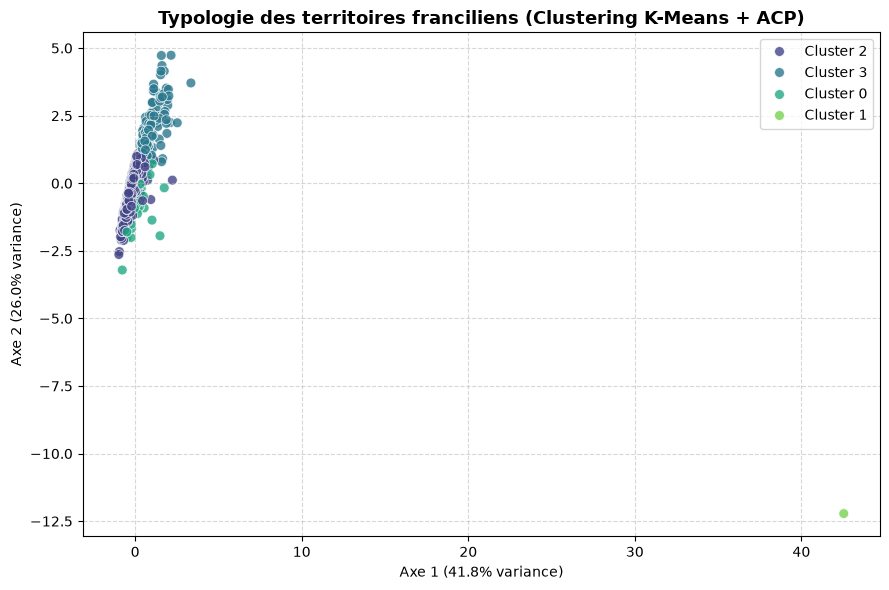

In [451]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Entraînement de K-Means (sur variables standardisées)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_tr_scaled)

# 2. Réduction dimensionnelle 2D par ACP pour visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tr_scaled)

df_pca = pd.DataFrame({
    "Axe 1": X_pca[:, 0],
    "Axe 2": X_pca[:, 1],
    "Cluster": [f"Cluster {c}" for c in clusters],
    "Target_log": y_train.values
})

# 3. Visualisation des clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca,
    x="Axe 1",
    y="Axe 2",
    hue="Cluster",
    palette="viridis",
    alpha=0.8,
    s=50
)
plt.title("Typologie des territoires franciliens (Clustering K-Means + ACP)", fontsize=13, fontweight="bold")
plt.xlabel(f"Axe 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Axe 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

##### Le graphique projette les $1\,012$ communes du jeu d'entraînement sur les deux premières composantes principales de l'ACP ($39,1\%$ de la variance totale) :Axe 1 ($32,1\%$ de la variance — Niveau d'équipement et urbanité) :Sépare les territoires de gauche à droite, depuis les communes peu denses et isolées (gauche) jusqu'aux pôles urbains très équipés (droite).Axe 2 ($7,0\%$ de la variance — Profil atypique / hyper-centralité) :Isole les concentrations extrêmes de services et de flux.Typologie des 4 profils territoriaux (Clusters) :Cluster 3 (Vert clair, point isolé en haut à gauche) : L'hyper-centre parisien / pôle mondial. Commune hors-norme qui concentre des volumes d'équipements sans équivalent francilien.Cluster 1 (Bleu canard, partie gauche) : Territoires ruraux et petite périphérie. Faible densité commerciale par habitant, dépendance aux communes voisines.Cluster 2 (Vert turquoise, zone médiane) : Communes périurbaines et petites villes. Équipements de première nécessité présents (boulangerie, école primaire, pharmacie), potentiel de restauration rapide modéré.Cluster 0 (Violet, partie droite étalée) : Centres urbains et pôles d'emploi denses. Forte densité bancaire, lycées, supermarchés et niveau de vie contrasté, constituant le cœur de cible naturel pour l'implantation de restauration rapide.

### Généralisation & Robustesse
#### A. Applicabilité à d'autres secteurs commerciaux (Transposabilité du pipeline) :Le pipeline est agnostique au type de commerce : il suffit de changer la cible $Y$ (ex. salle_remise_en_forme, boulangerie_patisserie, pharmacie).  Feature Engineering générique : Les densités pour $1\,000$ habitants et les ratios socio-économiques s'adaptent immédiatement à l'analyse de n'importe quelle enseigne de distribution ou de service de proximité.  Calcul d'indice d'opportunité : Pour tout commerce, la différence entre le prédit et le réel ($\hat{y} - y$) sert d'indicateur de sous-équipement commercial (zone à implanter en priorité).
#### B. Protocoles pour confirmer la pertinence sur de nouvelles données :Validation spatiale hors Île-de-France (Spatial Cross-Validation) : Tester le modèle entraîné en Île-de-France sur d'autres régions (Auvergne-Rhône-Alpes, Nouvelle-Aquitaine) via les bases nationales BPE et Filosofi de l'INSEE pour vérifier que les règles apprises ne sont pas biaisées par la structure parisienne.Backtesting temporel : Entraîner sur les données $N-2$ et prédire les ouvertures effectives de magasins constatées en $N$ pour mesurer la valeur prédictive dynamique.Surveillance du concept drift : Monitorer l'évolution des coefficients SHAP et des résidus chaque année lors de la mise à jour des millésimes de données INSEE.